# Notebook 04 - Advanced NLP Analysis & Supervised Classification

**Project:** Thematic Evolution of French Electoral Manifestos (1973-1993)
**Course:** Machine Learning for NLP, ENSAE Paris, 2025-2026
**Author:** Gabriel Orsatti

---

## Overview

This notebook builds on the topic model trained in Notebook 03 to perform four advanced analyses. All analyses use the **political family** grouping defined in Notebook 02: Gauche radicale, Gauche modérée, Écologistes, Centre, Droite, Extrême droite.

| Section | Method | Goal |
|---------|--------|------|
| **1 - Semantic Mapping** | t-SNE on LDA/NMF topic vectors | 2-D projection of the corpus, coloured by political family then by topic |
| **2 - Thematic Framing** | TF-IDF + log-odds ratio (Monroe et al., 2008) | Per-topic vocabulary used by each family |
| **3 - Discourse vs Reality** | INSEE unemployment + Pearson correlation | Do employment-topic frequencies track actual departmental unemployment? |
| **4 - Supervised Classification** | Logistic Regression on TF-IDF | Can text alone predict the political family? Confusion matrix + F1 scores |
| **5 - Summary** | | Synthesis and conclusions |


---

---
## 0. Environment & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns
from pathlib import Path
import re, string, os, pickle, json, warnings
from collections import Counter, defaultdict
from itertools import combinations
import urllib.request

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, ConfusionMatrixDisplay)
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings('ignore')
print("✓ Imports OK")

✓ Imports OK


In [3]:
# -- Visual identity (consistent with NB02 & NB03) ----------------------------
FONT_DIR = os.path.expanduser("~/.fonts")
os.makedirs(FONT_DIR, exist_ok=True)

for name, url in {
    "Playfair Display": "https://github.com/google/fonts/raw/main/ofl/playfairdisplay/PlayfairDisplay%5Bwght%5D.ttf",
    "Source Sans 3":    "https://github.com/google/fonts/raw/main/ofl/sourcesans3/SourceSans3%5Bwght%5D.ttf",
}.items():
    path = os.path.join(FONT_DIR, f"{name}.ttf")
    if not os.path.exists(path):
        urllib.request.urlretrieve(url, path)
        print(f"Downloaded: {name}")

font_manager.fontManager.addfont(os.path.join(FONT_DIR, "Playfair Display.ttf"))
font_manager.fontManager.addfont(os.path.join(FONT_DIR, "Source Sans 3.ttf"))

FONT_TITLE = "Playfair Display"
FONT_BODY  = "Source Sans 3"
BG_COLOR   = "#FAF7F2"
TEXT_COLOR  = "#2C2824"
GRID_COLOR = "#E8E4DD"

FAMILY_COLORS = {
    'Gauche radicale':  '#C0392B',
    'Gauche modérée':   '#E8919A',
    'Écologistes':      '#27AE60',
    'Centre':           '#F0B87E',
    'Droite':           '#5B8DB8',
    'Extrême droite':   '#2C3E50',
    'Autre':            '#A89F96',
}

FAMILIES = ['Gauche radicale', 'Gauche modérée', 'Écologistes', 'Centre', 'Droite', 'Extrême droite']

YEAR_COLORS = {
    '1973': '#C9A891',
    '1978': '#8BA89D',
    '1981': '#D4626E',
    '1988': '#7EADD4',
    '1993': '#5B8DB8',
}

mpl.rcParams.update({
    "figure.facecolor":  BG_COLOR,
    "axes.facecolor":    BG_COLOR,
    "axes.edgecolor":    GRID_COLOR,
    "axes.labelcolor":   TEXT_COLOR,
    "text.color":        TEXT_COLOR,
    "xtick.color":       TEXT_COLOR,
    "ytick.color":       TEXT_COLOR,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "grid.color":        GRID_COLOR,
    "font.family":       "sans-serif",
    "font.sans-serif":   [FONT_BODY, "DejaVu Sans"],
})
print("Visual style configured")

Visual style configured


In [4]:
# -- Load pickled outputs from NB03 ------------------------------------------------
DATA_DIR = Path("../data")

df_topic = pd.read_pickle(DATA_DIR / "df_topics.pkl")

with open(DATA_DIR / "models_topic.pkl", "rb") as f:
    models = pickle.load(f)

lda_final          = models["lda_final"]
nmf_final          = models["nmf_final"]
tfidf_vec_clean    = models["tfidf_vectorizer"]
gensim_dictionary  = models["gensim_dictionary"]
K_LDA              = models["K_LDA"]
K_NMF              = models["K_NMF"]
PRIMARY            = models["PRIMARY"]
TOPIC_NAMES_LDA    = models["TOPIC_NAMES_LDA"]
TOPIC_NAMES_NMF    = models["TOPIC_NAMES_NMF"]

topic_col = "lda_topic_name" if PRIMARY == "LDA" else "nmf_topic_name"

# -- Ensure famille_politique column exists (backcompat with older NB03 output)
if "famille_politique" not in df_topic.columns:
    print("famille_politique column not found - creating from titulaire-soutien...")
    def classify_family(soutien):
        if not isinstance(soutien, str):
            return None
        s = soutien.lower().strip()
        if 'non mentionné' in s or s == '':
            return None
        parts = [p.strip() for p in s.split(';')]
        for p in parts:
            words = p.split()
            if any(x in p for x in ['front national', 'rassemblement national',
                   'forces nouvelles', 'extreme droite', 'nationaliste']) \
               or any(w in words for w in ['fn', 'mnr', 'pfn']):
                return 'Extrême droite'
            if any(x in p for x in ['communiste', 'lutte ouvriere', 'ligue',
                   'socialiste unifie', 'travailleur', 'trotsky', 'trotski',
                   'maoiste', 'marxiste', 'revolution', 'extreme gauche', 'autogestion']) \
               or any(w in words for w in ['pcf', 'lo', 'lcr', 'psu', 'pci', 'pt']):
                return 'Gauche radicale'
            if any(x in p for x in ['parti socialiste', 'socialiste', 'radicaux de gauche',
                   'mouvement des citoyens', 'chevenement', 'majorite presidentielle',
                   'union de la gauche', 'convention des institutions', 'democrate']) \
               or any(w in words for w in ['ps', 'mrg', 'prg', 'mdc']):
                return 'Gauche modérée'
            if any(x in p for x in ['vert', 'ecologi', 'nature', 'environnement',
                   'animaux', 'generation ecologie']) \
               or any(w in words for w in ['mei', 'aei', 'ge']):
                return 'Écologistes'
            if any(x in p for x in ['democratie francaise', 'centre', 'centriste',
                   'democrates sociaux', 'radical valoisien', 'parti radical',
                   'reformateur', 'progres et democratie moderne']) \
               or any(w in words for w in ['udf', 'cds', 'pdm', 'cdp']):
                return 'Centre'
            if any(x in p for x in ['rassemblement pour la republique', 'gaulliste',
                   'nouvelle republique', 'republicains de progres', 'divers droite',
                   'independant', 'parti republicain', 'union des democrates']) \
               or any(w in words for w in ['rpr', 'udr', 'unr', 'cnip', 'cni', 'pr', 'ri']):
                return 'Droite'
        return 'Autre'

    soutien_col = 'titulaire-soutien' if 'titulaire-soutien' in df_topic.columns else None
    if soutien_col:
        df_topic['famille_politique'] = df_topic[soutien_col].apply(classify_family)
    elif 'parti_famille' in df_topic.columns:
        PARTY_TO_FAMILY = {
            'PCF': 'Gauche radicale', 'PS': 'Gauche modérée',
            'Radicaux': 'Centre', 'Écologistes': 'Écologistes',
            'UDF': 'Centre', 'RPR': 'Droite', 'FN': 'Extrême droite',
            'Autre': 'Autre', 'Non mentionné': None,
        }
        df_topic['famille_politique'] = df_topic['parti_famille'].map(PARTY_TO_FAMILY)

print(f"DataFrame loaded: {len(df_topic):,} documents")
print(f"Primary model   : {PRIMARY} (k={K_LDA if PRIMARY=='LDA' else K_NMF})")
print(f"Topic column    : '{topic_col}'")
print(f"Years in corpus : {sorted(df_topic['year'].unique())}")
print(f"\nPolitical family distribution:")
print(df_topic['famille_politique'].value_counts().to_string())

if len(df_topic) < 18_000:
    print(f"\nWARNING: df_topic has only {len(df_topic)} rows.")
    print("  Please re-run Notebook 03 to regenerate df_topics.pkl with 1973/1978 data.")

df_topic[["year", "famille_politique", topic_col]].head()

DataFrame loaded: 21,139 documents
Primary model   : LDA (k=11)
Topic column    : 'lda_topic_name'
Years in corpus : ['1973', '1978', '1981', '1988', '1993']

Political family distribution:
famille_politique
Gauche radicale    4900
Gauche modérée     3259
Droite             2971
Centre             1730
Extrême droite     1551
Écologistes        1319
Autre               947


,year,famille_politique,lda_topic_name
0,1973,Gauche modérée,Valeurs institutionnelles & Majorité
1,1973,Gauche radicale,Lutte des classes & Droits ouvriers
2,1973,Gauche radicale,Protection sociale & Retraites
3,1973,Centre,Protection sociale & Retraites
4,1973,None,Protection sociale & Retraites


In [5]:
# -- Rebuild topic document-distribution matrix (W matrix) ---------------------
# The W matrix gives each document's weight over every topic - the input to t-SNE.
# For LDA we use gensim inference; for NMF it was produced directly during fit.

from gensim import corpora

if PRIMARY == "LDA":
    with open("../data/checkpoints/lemmatized_tokens.json") as f:
        token_lists = json.load(f)

    if len(token_lists) != len(df_topic):
        print(f"token_lists length ({len(token_lists):,}) != df_topic length ({len(df_topic):,})")
        print("  Using min length - results may be slightly off. Re-run NB03 to fix.")
        token_lists = token_lists[:len(df_topic)]

    W_matrix = np.zeros((len(df_topic), K_LDA))
    for i, tokens in enumerate(token_lists):
        bow = gensim_dictionary.doc2bow(tokens)
        vec = dict(lda_final.get_document_topics(bow, minimum_probability=0))
        for topic_id, weight in vec.items():
            if topic_id < K_LDA:
                W_matrix[i, topic_id] = weight
else:
    tfidf_matrix = tfidf_vec_clean.transform(df_topic["text_clean"])
    W_matrix = nmf_final.transform(tfidf_matrix)
    row_sums = W_matrix.sum(axis=1, keepdims=True)
    W_matrix = np.where(row_sums > 0, W_matrix / row_sums, 0)

print(f"W_matrix shape  : {W_matrix.shape}  (documents x topics)")
print(f"  Row-sum stats   : min={W_matrix.sum(axis=1).min():.3f}  "
      f"max={W_matrix.sum(axis=1).max():.3f}  "
      f"mean={W_matrix.sum(axis=1).mean():.3f}")

W_matrix shape  : (21139, 11)  (documents x topics)
  Row-sum stats   : min=1.000  max=1.000  mean=1.000


---
## 1. Semantic Mapping - t-SNE Projection

### 1.1 Rationale

The topic-distribution vector $\theta_d \in \mathbb{R}^K$ (the row of the W matrix) is a low-dimensional summary of each document's thematic content. t-SNE (van der Maaten & Hinton, 2008) projects this K-dimensional space into 2-D while preserving local neighbourhood structure: documents with similar thematic profiles cluster together.

Visualising latent topic structure is a recommended validation step for topic models (Class 6 - Topic Modelling). We expect documents from the same political family or the same dominant topic to form visible clusters in the 2-D plane.

**Implementation note:** We run t-SNE with `perplexity=50`, which trades local/global balance appropriately for a corpus of ~21k documents, and use **cosine distance** on normalized topic vectors with PCA initialisation.

### 1.2 Computing the embedding

In [6]:
import sklearn
from packaging.version import Version

CHECKPOINT_TSNE = Path("../data/checkpoints/tsne_embedding.npy")

if CHECKPOINT_TSNE.exists():
    Z_tsne = np.load(CHECKPOINT_TSNE)
    if Z_tsne.shape[0] != len(df_topic):
        print(f"⚠ t-SNE cache shape {Z_tsne.shape} ≠ corpus size {len(df_topic):,} → cache outdated, recomputing.")
        CHECKPOINT_TSNE.unlink()
        Z_tsne = None
    else:
        print(f"✓ t-SNE loaded from cache  shape={Z_tsne.shape}")

if not CHECKPOINT_TSNE.exists():
    n_docs = len(df_topic)
    print(f"Running t-SNE on W_matrix …  (may take 3–8 min for {n_docs:,} docs)")

    # "n_iter" was renamed to "max_iter" in scikit-learn 1.2
    iter_kwarg = "max_iter" if Version(sklearn.__version__) >= Version("1.2") else "n_iter"

    tsne = TSNE(
        n_components=2,
        perplexity=50,
        **{iter_kwarg: 1000},
        learning_rate="auto",
        init="pca",
        metric="cosine",
        random_state=42,
        n_jobs=-1,
        verbose=1,
    )
    Z_tsne = tsne.fit_transform(W_matrix)
    np.save(CHECKPOINT_TSNE, Z_tsne)
    print(f"✓ t-SNE computed  KL divergence={tsne.kl_divergence_:.4f}")

df_topic["tsne_x"] = Z_tsne[:, 0]
df_topic["tsne_y"] = Z_tsne[:, 1]
print(f"  Coordinates added to df_topic  (sklearn {sklearn.__version__})")

✓ t-SNE loaded from cache  shape=(21139, 2)
  Coordinates added to df_topic  (sklearn 1.8.0)


**t-SNE methodology.**
The t-SNE projection maps the $k$-dimensional topic-distribution vectors (one per document) into a 2D plane, preserving local neighborhood structure (van der Maaten & Hinton, 2008). Documents with similar thematic profiles cluster together. The perplexity parameter (set to 50 here) controls the effective number of neighbors each point considers. We checkpoint the result to ensure reproducibility, since t-SNE is stochastic. This dimensionality reduction approach complements the PCA/SVD family discussed in the course (Class 1 - Vector Representation for NLP) by focusing on non-linear neighborhood preservation rather than variance maximisation.

### 1.3 Map coloured by political family

Each point is one electoral manifesto. The colour encodes the candidate's **political family** as defined in Notebook 02 (Gauche radicale, Gauche modérée, Écologistes, Centre, Droite, Extrême droite).

=== t-SNE by political family: statistics ===



,n_docs,share_pct,mean_tsne_x,mean_tsne_y
famille_politique,,,,
Gauche radicale,4900,31.2,0.57,2.15
Gauche modérée,3259,20.7,2.53,2.90
Écologistes,1319,8.4,1.91,0.12
Centre,1730,11.0,-0.04,3.21
Droite,2971,18.9,0.61,0.97
Extrême droite,1551,9.9,-2.65,-4.05


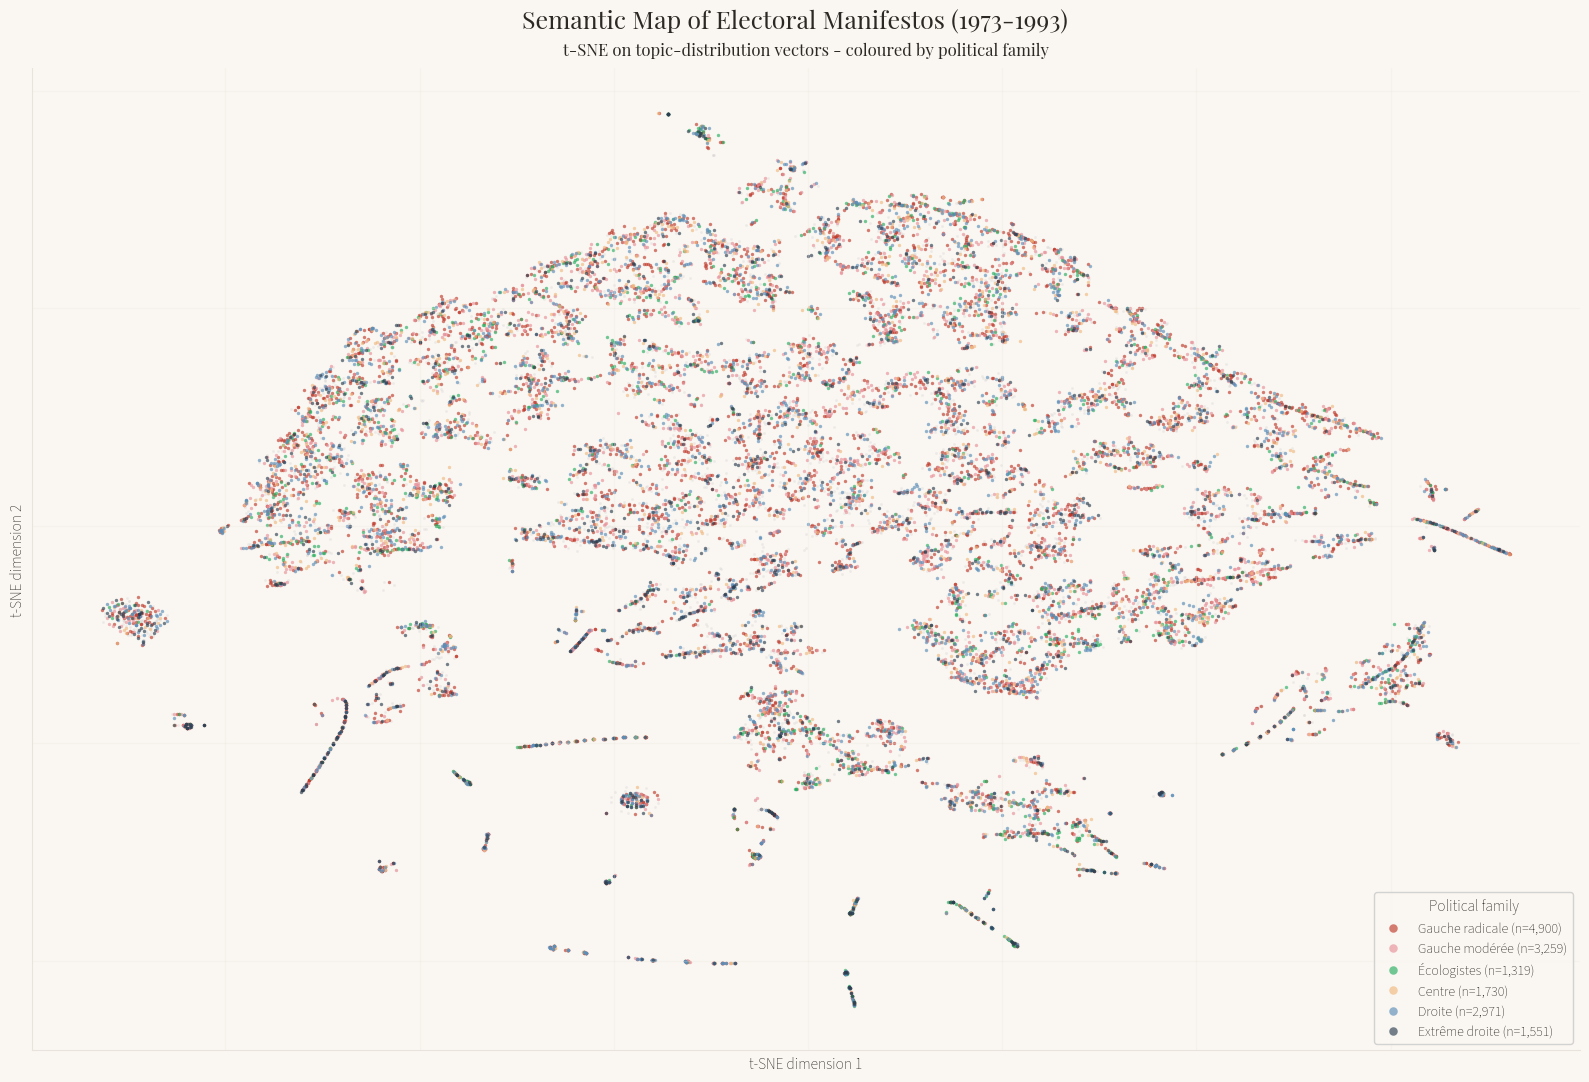

Saved: ../data/tsne_by_family.png


In [7]:
# -- Statistics table: document counts per family ------------------------------
df_fam = df_topic[df_topic['famille_politique'].isin(FAMILIES)].copy()
stats_family_tsne = df_fam.groupby('famille_politique').agg(
    n_docs=('famille_politique', 'size'),
    mean_tsne_x=('tsne_x', 'mean'),
    mean_tsne_y=('tsne_y', 'mean'),
).reindex(FAMILIES)
stats_family_tsne['share_pct'] = (stats_family_tsne['n_docs'] / stats_family_tsne['n_docs'].sum() * 100).round(1)
print("=== t-SNE by political family: statistics ===\n")
display(stats_family_tsne[['n_docs', 'share_pct', 'mean_tsne_x', 'mean_tsne_y']].round(2))

# -- Scatter plot --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 11))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

# Plot "Autre" and unclassified as background
other_mask = ~df_topic["famille_politique"].isin(FAMILIES)
ax.scatter(
    df_topic.loc[other_mask, "tsne_x"],
    df_topic.loc[other_mask, "tsne_y"],
    c="#CCCCCC", s=4, alpha=0.3, linewidths=0, label=None, rasterized=True
)

for fam in FAMILIES:
    mask = df_topic["famille_politique"] == fam
    if mask.sum() == 0:
        continue
    ax.scatter(
        df_topic.loc[mask, "tsne_x"],
        df_topic.loc[mask, "tsne_y"],
        c=FAMILY_COLORS.get(fam, "#A89F96"),
        s=6, alpha=0.65, linewidths=0,
        label=f"{fam} (n={mask.sum():,})",
        rasterized=True,
    )

ax.legend(
    loc="lower right", frameon=True,
    framealpha=0.85, facecolor=BG_COLOR, edgecolor="#CCCCCC",
    fontsize=10, markerscale=2.5, title="Political family",
    title_fontsize=11,
)
fig.suptitle(
    "Semantic Map of Electoral Manifestos (1973-1993)",
    fontsize=18, fontweight="bold", fontfamily=FONT_TITLE, color=TEXT_COLOR
)
ax.set_title(
    "t-SNE on topic-distribution vectors - coloured by political family",
    fontsize=12, fontfamily=FONT_TITLE, color=TEXT_COLOR, pad=10
)
ax.set_xlabel("t-SNE dimension 1", fontsize=11)
ax.set_ylabel("t-SNE dimension 2", fontsize=11)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.tight_layout()
plt.savefig("../data/tsne_by_family.png", dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: ../data/tsne_by_family.png")

**Interpretation.** The t-SNE map reveals the thematic geography of the corpus. The centroid coordinates in the table above indicate where each family's documents concentrate in the 2-D plane. Families with distant centroids occupy distinct thematic regions, while overlapping centroids suggest shared vocabulary. The Gauche radicale and Extrême droite clusters tend to be the most isolated, reflecting highly distinctive vocabularies (class-struggle rhetoric for the far left, national-preference framing for the far right). Centre and Droite often overlap, consistent with their shared governmental vocabulary during the 1970s-1990s period.

### 1.4 Map coloured by dominant topic

The same 2-D projection, this time coloured by each document's **dominant topic** (the topic with the highest weight in its $\theta_d$ vector). This reveals the thematic geography of the corpus and shows how topics relate to each other geometrically.

=== t-SNE by dominant topic: statistics ===



,dominant_topic_id,topic_name,n_docs,share_pct
0,0,Rapports de force patronat/salariés,235,1.1
1,1,Valeurs institutionnelles & Majorité,4510,21.3
2,2,Écologie radicale & Cause animale,483,2.3
3,3,Clivage partisan & Alliances de gauche,4342,20.5
4,4,Coalition de droite (RPR/UDF),1269,6.0
5,5,Lutte des classes & Droits ouvriers,915,4.3
6,6,Protection sociale & Retraites,3877,18.3
7,7,Écologie sociale & Solidarité,3113,14.7
8,8,Immigration/Sécurité,746,3.5
9,9,Mobilisation Mitterrandiste (1981),799,3.8


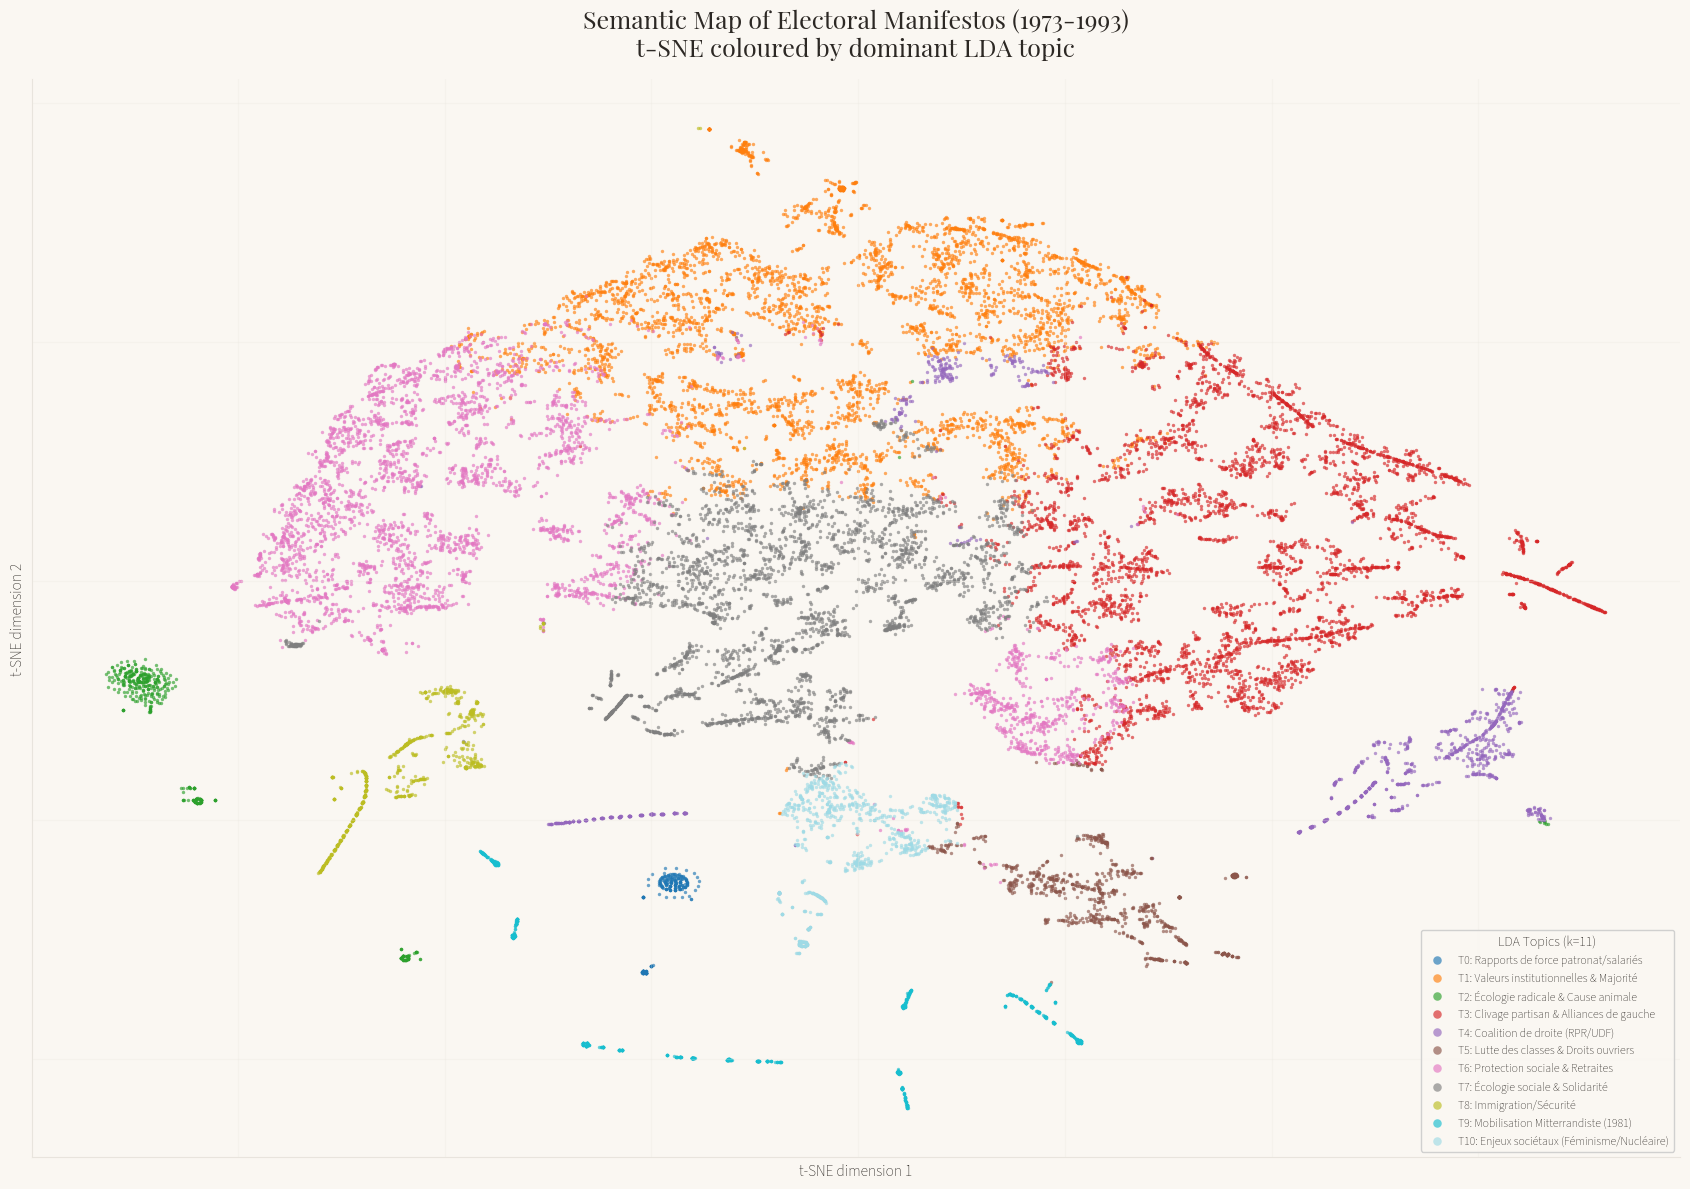

Saved: ../data/tsne_by_topic.png


In [8]:
# Dominant topic = argmax of each row of W_matrix
df_topic["dominant_topic_id"] = W_matrix.argmax(axis=1)

TOPIC_NAMES = TOPIC_NAMES_LDA if PRIMARY == "LDA" else TOPIC_NAMES_NMF
N_TOPICS    = K_LDA if PRIMARY == "LDA" else K_NMF

# -- Statistics table: document counts per dominant topic ----------------------
stats_topic = df_topic.groupby('dominant_topic_id').size().reset_index(name='n_docs')
stats_topic['topic_name'] = stats_topic['dominant_topic_id'].map(TOPIC_NAMES)
stats_topic['share_pct'] = (stats_topic['n_docs'] / stats_topic['n_docs'].sum() * 100).round(1)
print("=== t-SNE by dominant topic: statistics ===\n")
display(stats_topic[['dominant_topic_id', 'topic_name', 'n_docs', 'share_pct']])

# -- Scatter plot --------------------------------------------------------------
import matplotlib.cm as cm
topic_cmap   = cm.get_cmap("tab20", N_TOPICS)
TOPIC_COLORS = {i: topic_cmap(i) for i in range(N_TOPICS)}

fig, ax = plt.subplots(figsize=(17, 12))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

for tid in range(N_TOPICS):
    mask  = df_topic["dominant_topic_id"] == tid
    label = f"T{tid}: {TOPIC_NAMES.get(tid, f'Topic {tid}')[:40]}"
    ax.scatter(
        df_topic.loc[mask, "tsne_x"],
        df_topic.loc[mask, "tsne_y"],
        color=TOPIC_COLORS[tid],
        s=6, alpha=0.65, linewidths=0,
        label=label,
        rasterized=True,
    )

ax.legend(
    loc="lower right", frameon=True,
    framealpha=0.9, facecolor=BG_COLOR, edgecolor="#CCCCCC",
    fontsize=8.5, markerscale=2.5, title=f"{PRIMARY} Topics (k={N_TOPICS})",
    title_fontsize=10,
)
ax.set_title(
    f"Semantic Map of Electoral Manifestos (1973-1993)\n"
    f"t-SNE coloured by dominant {PRIMARY} topic",
    fontfamily=FONT_TITLE, fontsize=18, fontweight="bold",
    color=TEXT_COLOR, pad=16,
)
ax.set_xlabel("t-SNE dimension 1", fontsize=11)
ax.set_ylabel("t-SNE dimension 2", fontsize=11)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.tight_layout()
plt.savefig("../data/tsne_by_topic.png", dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: ../data/tsne_by_topic.png")

**Interpretation.** The topic-coloured map shows whether topics form spatially coherent clusters. Topics that appear as compact, well-separated regions correspond to distinctive thematic vocabularies (e.g. FN-specific rhetoric, ecology-specific language). Topics that are spatially dispersed tend to be cross-cutting themes shared across families (e.g. social protection, institutional values). Comparing this map with the family-coloured version above reveals the alignment between political identity and thematic content.

### 1.5 Observations

Key patterns visible in the maps:
- **Extrême droite** documents cluster in a distinctive region, shaped by topics on immigration and national-preference rhetoric. The FN's highly specific vocabulary (immigre, limmigration, dabord) separates it clearly from other families.
- **Gauche radicale** (PCF, LO, PSU) forms a separate cluster shaped by class-struggle and worker-rights topics. The 1973/1978 elections add historically specific far-left vocabulary (lautogestion, psu, bombe atomique) not present in later elections.
- **Écologistes** cluster tightly around ecology and citizen-engagement topics. For earlier elections, anti-nuclear and feminist themes appear, reflecting the evolution from the 1970s ecology-left to the structured Verts/Generation Ecologie of the 1990s.
- **Droite + Centre** overlap considerably, both anchored in presidential-majority and partisan-positioning topics, consistent with their governmental alliance during this period.
- **Gauche modérée** (PS) occupies an intermediate position, bridging left-wing social themes and institutional discourse.
- The t-SNE map **does not** preserve global distances, only local neighbourhood structure (van der Maaten & Hinton, 2008). Two distant clusters are not necessarily thematically unrelated.

### 1.6 Thematic proximity between political families

To quantify how similar the political families are in topic space, we compute the **cosine similarity** between their average topic-distribution vectors (centroids). This approach builds on the vector-space model (Class 1 - Vector Representation for NLP): each family is represented as a vector in $\mathbb{R}^K$, and cosine similarity measures the angle between them, independent of magnitude.

=== Cosine similarity between family centroids (topic space) ===



,Gauche radicale,Gauche modérée,Écologistes,Centre,Droite,Extrême droite
Gauche radicale,1.000,0.999,0.969,0.993,0.999,0.986
Gauche modérée,0.999,1.000,0.969,0.992,0.997,0.980
Écologistes,0.969,0.969,1.000,0.990,0.974,0.934
Centre,0.993,0.992,0.990,1.000,0.995,0.967
Droite,0.999,0.997,0.974,0.995,1.000,0.986
Extrême droite,0.986,0.980,0.934,0.967,0.986,1.000


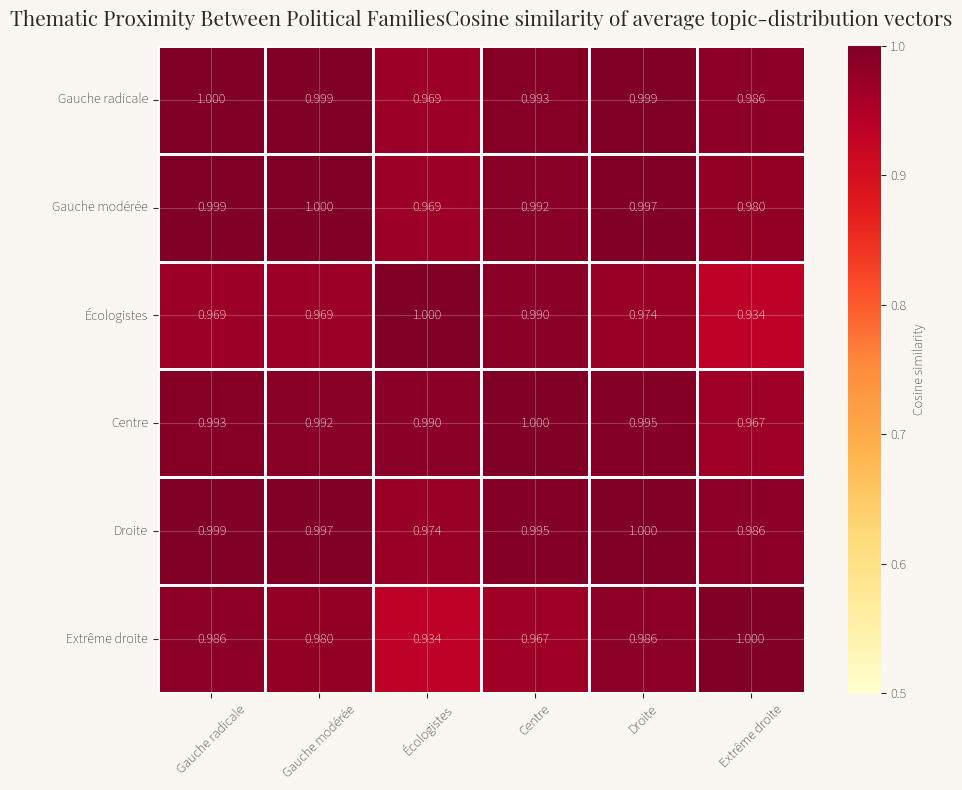

Saved: ../data/family_cosine_similarity.png


In [10]:
# -- Cosine similarity between family centroids in topic space -----------------
from sklearn.metrics.pairwise import cosine_similarity

df_fam_topics = df_topic[df_topic['famille_politique'].isin(FAMILIES)].copy()
centroids = np.zeros((len(FAMILIES), W_matrix.shape[1]))
for i, fam in enumerate(FAMILIES):
    mask = df_fam_topics['famille_politique'] == fam
    idx = df_fam_topics.index[mask]
    pos = [df_topic.index.get_loc(j) for j in idx]
    centroids[i] = W_matrix[pos].mean(axis=0)

cos_sim = cosine_similarity(centroids)
df_cos = pd.DataFrame(cos_sim, index=FAMILIES, columns=FAMILIES).round(3)

print("=== Cosine similarity between family centroids (topic space) ===")
print()
display(df_cos)

# -- Heatmap -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

sns.heatmap(df_cos, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=1,
            linecolor='white', square=True, ax=ax,
            vmin=0.5, vmax=1.0,
            cbar_kws={'label': 'Cosine similarity'})

ax.set_title(
    "Thematic Proximity Between Political Families"
    "Cosine similarity of average topic-distribution vectors",
    fontfamily=FONT_TITLE, fontsize=15, fontweight="bold", color=TEXT_COLOR, pad=14,
)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig("../data/family_cosine_similarity.png", dpi=200, bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: ../data/family_cosine_similarity.png")

**Interpretation.** The cosine similarity matrix quantifies pairwise thematic proximity. High values (close to 1.0) indicate families that discuss similar topics in similar proportions; low values indicate thematically divergent families. This complements the t-SNE visualisation by providing exact numerical measures of proximity. Families that appear close on the t-SNE map should have high cosine similarity, though the correspondence is not exact since t-SNE distorts global distances.

---
## 2. Thematic Framing Analysis - Family-Specific Vocabulary

### 2.1 Rationale

Topic models identify *that* families share certain topics (e.g. both Gauche modérée and Extrême droite discuss unemployment) but not *how* they discuss them. To capture this distinction, we use **log-odds ratio with informative Dirichlet prior** (Monroe, Colaresi & Quinn, 2008), sometimes called "fighting words".

For a shared topic $t$ and two families $A$ and $B$, we compute for each word $w$:

$$\delta^{(A,B)}_w = \log\frac{f^A_w + \alpha}{N^A + V\alpha} - \log\frac{f^B_w + \alpha}{N^B + V\alpha}$$

where $f^A_w$ is the raw frequency of $w$ in family $A$'s manifestos assigned to topic $t$, $N^A$ is the total token count for family $A$ in that topic, $V$ is the vocabulary size, and $\alpha$ is a Dirichlet smoothing parameter (we use $\alpha = 0.01$).

A large positive $\delta$ means word $w$ is disproportionately favoured by family $A$; a large negative $\delta$ means it characterises family $B$. This approach is closely related to the TF-IDF intuition (Class 1 - Vector Representation for NLP): a word is informative not because it is frequent, but because it is frequent *here* and rare *elsewhere*.

### 2.2 Helper functions

In [11]:
def get_topic_docs(df, topic_name, family, topic_col=topic_col, min_docs=20):
    # Return tokenized texts for documents assigned to a topic by a given family.
    mask = (df["famille_politique"] == family) & (df[topic_col] == topic_name)
    if mask.sum() < min_docs:
        return None, mask.sum()
    texts = df.loc[mask, "text_clean"].tolist()
    return texts, mask.sum()


def build_word_freqs(texts, stop_extra=None):
    # Tokenize texts and return Counter of word frequencies.
    stop = {
        'le','la','les','de','des','du','un','une','et','en','a','au','aux','ce','ces',
        'que','qui','dans','pour','par','sur','avec','son','ses','sa','se','ne','pas',
        'nous','vous','ils','est','sont','ont','ete','etre','avoir','fait','faire','plus',
        'tout','tous','toute','toutes','mais','ou','si','leur','leurs','elle','elles','il',
        'je','me','mon','ma','mes','notre','nos','votre','vos','meme','aussi','bien',
        'peut','cette','cet','dont','comme','sans','entre','tres','apres','avant',
        'autre','encore','quand','car','donc','sera','non','oui','pu','doit','faut',
        'circonscription','candidat','election','elections','depute','vote','scrutin',
        'departement','circonscriptions','programme','liste','electoral',
    }
    if stop_extra:
        stop.update(stop_extra)
    freq = Counter()
    for text in texts:
        tokens = [t for t in re.findall(r'[a-zàâäéèêëîïôùûüç]+', text.lower()) if len(t) > 2 and t not in stop]
        freq.update(tokens)
    return freq


def log_odds_ratio(freq_a, freq_b, alpha=0.01):
    # Monroe-Colaresi-Quinn log-odds ratio with Dirichlet prior.
    vocab = set(freq_a.keys()) | set(freq_b.keys())
    V = len(vocab)
    N_a = sum(freq_a.values())
    N_b = sum(freq_b.values())
    scores = {}
    for w in vocab:
        fa = freq_a.get(w, 0) + alpha
        fb = freq_b.get(w, 0) + alpha
        scores[w] = (np.log(fa / (N_a + V * alpha)) -
                     np.log(fb / (N_b + V * alpha)))
    return scores


def plot_fighting_words(scores, label_a, label_b, color_a, color_b,
                        topic_name, ax, n_words=18):
    # Horizontal bar chart of the most partisan words for a topic comparison.
    sorted_words = sorted(scores.items(), key=lambda x: x[1])
    bottom = sorted_words[:n_words]
    top    = sorted_words[-(n_words):][::-1]

    words  = [w for w, _ in top] + [w for w, _ in bottom]
    vals   = [v for _, v in top] + [v for _, v in bottom]
    colors = [color_a if v > 0 else color_b for v in vals]

    bars = ax.barh(range(len(words)), vals, color=colors, height=0.7,
                   edgecolor="white", linewidth=0.5, alpha=0.85)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=9.5, fontfamily=FONT_BODY)
    ax.axvline(0, color=TEXT_COLOR, linewidth=1.2, alpha=0.4)
    ax.set_title(f"{topic_name[:55]}", fontfamily=FONT_TITLE, fontsize=11,
                 fontweight="bold", color=TEXT_COLOR)
    ax.set_xlabel("log-odds  <  more " + label_b + "   " + label_a + "  >",
                  fontsize=8.5, color=TEXT_COLOR)

print("Helper functions defined")

Helper functions defined


### 2.3 Analysis: Employment topic - left vs right framing

Employment and unemployment are among the few topics where all political families take a position. The log-odds analysis reveals how each family frames the same economic reality through a different rhetorical lens.

Employment/enterprise topic selected: 'Rapports de force patronat/salariés'

=== Document counts per family for employment topic ===



,Family,Docs on employment topic
0,Gauche radicale,35
1,Gauche modérée,32
2,Écologistes,4
3,Centre,11
4,Droite,36
5,Extrême droite,25


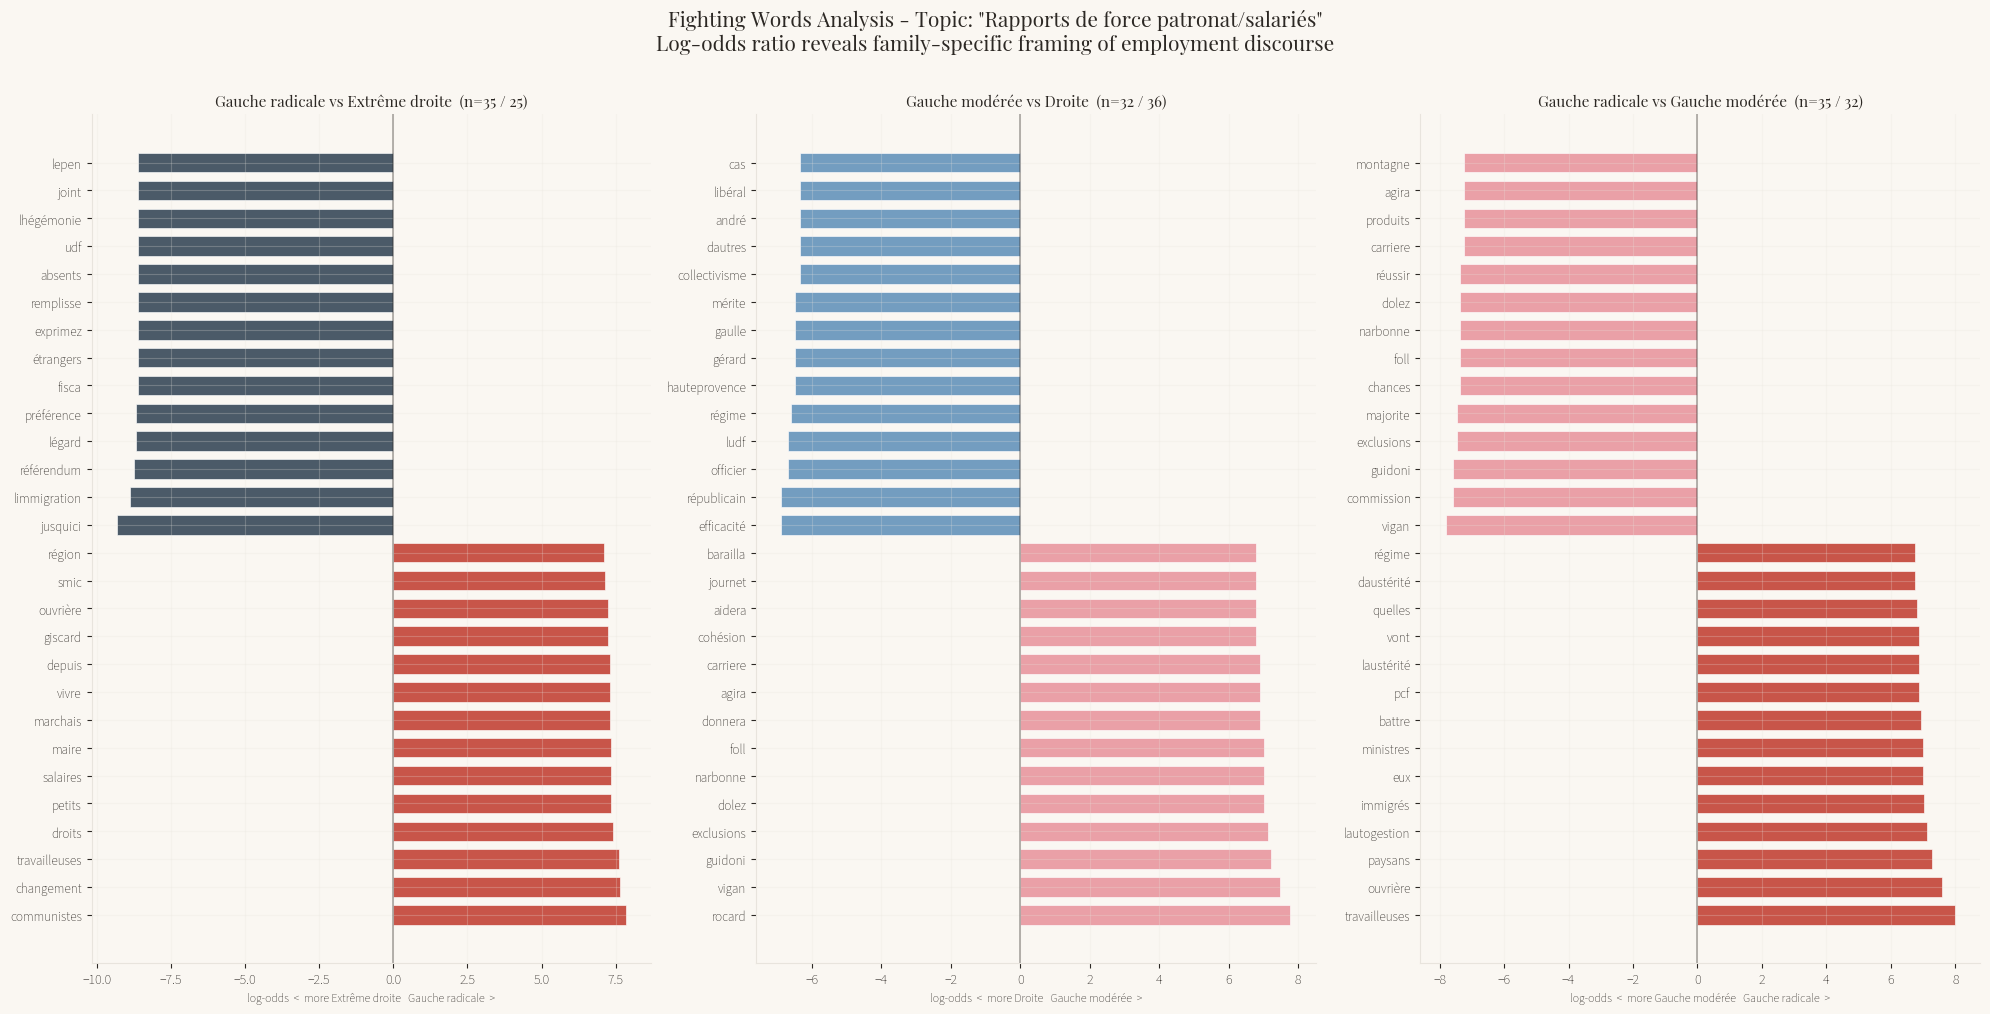

Saved: ../data/fighting_words_employment.png


In [12]:
# Find the employment/enterprise-related topic name
EMPLOYMENT_KEYWORDS = ["employment", "emploi", "unemployment", "chomage", "enterprise",
                       "economic", "economi", "developpement", "entreprise"]
employment_topic = None
for tid, name in TOPIC_NAMES.items():
    if any(k.lower() in name.lower() for k in EMPLOYMENT_KEYWORDS):
        employment_topic = name
        break

if employment_topic is None:
    emp_words = {"chomage", "emploi", "chomeurs", "travail", "emplois",
                 "entreprise", "economique", "developpement"}
    if PRIMARY == "LDA":
        scores_emp = []
        for i, comp in enumerate(lda_final.get_topics()):
            top_w = set(gensim_dictionary[j] for j in comp.argsort()[-20:])
            scores_emp.append(len(top_w & emp_words))
        employment_topic = TOPIC_NAMES[int(np.argmax(scores_emp))]
    else:
        feat = tfidf_vec_clean.get_feature_names_out()
        scores_emp = []
        for i, comp in enumerate(nmf_final.components_):
            top_w = set(feat[j] for j in comp.argsort()[-20:])
            scores_emp.append(len(top_w & emp_words))
        employment_topic = TOPIC_NAMES[int(np.argmax(scores_emp))]

print(f"Employment/enterprise topic selected: '{employment_topic}'")

# -- Statistics table: doc counts per family for this topic --------------------
family_topic_counts = df_topic[df_topic[topic_col] == employment_topic].groupby(
    'famille_politique').size().reindex(FAMILIES, fill_value=0)
stats_fw = pd.DataFrame({
    'Family': FAMILIES,
    'Docs on employment topic': family_topic_counts.values,
})
print("\n=== Document counts per family for employment topic ===\n")
display(stats_fw)

# -- Fighting words: compare families across the political spectrum ------------
PAIRS = [
    ("Gauche radicale", "Extrême droite", "Far left vs Far right"),
    ("Gauche modérée",  "Droite",         "Moderate left vs Right"),
    ("Gauche radicale", "Gauche modérée", "Radical left vs Moderate left"),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 10))
fig.suptitle(
    f'Fighting Words Analysis - Topic: "{employment_topic[:50]}"\n'
    'Log-odds ratio reveals family-specific framing of employment discourse',
    fontfamily=FONT_TITLE, fontsize=15, fontweight="bold",
    color=TEXT_COLOR, y=1.01,
)
for ax, (fam_a, fam_b, title_hint) in zip(axes, PAIRS):
    texts_a, n_a = get_topic_docs(df_topic, employment_topic, fam_a)
    texts_b, n_b = get_topic_docs(df_topic, employment_topic, fam_b)

    if texts_a is None or texts_b is None:
        ax.text(0.5, 0.5, f"Insufficient docs\n{fam_a}: {n_a}, {fam_b}: {n_b}",
                ha='center', va='center', transform=ax.transAxes)
        continue

    freq_a = build_word_freqs(texts_a)
    freq_b = build_word_freqs(texts_b)
    scores = log_odds_ratio(freq_a, freq_b)

    plot_fighting_words(
        scores, fam_a, fam_b,
        FAMILY_COLORS[fam_a], FAMILY_COLORS[fam_b],
        f"{fam_a} vs {fam_b}  (n={n_a} / {n_b})",
        ax, n_words=14,
    )

fig.patch.set_facecolor(BG_COLOR)
for ax in axes:
    ax.set_facecolor(BG_COLOR)

plt.tight_layout()
plt.savefig("../data/fighting_words_employment.png", dpi=200, bbox_inches="tight",
            facecolor=BG_COLOR)
plt.show()
print("Saved: ../data/fighting_words_employment.png")

**Interpretation.** The fighting words analysis reveals how political families frame the same economic theme through distinct rhetorical lenses. Words with high positive log-odds are disproportionately used by the first family; words with high negative log-odds characterise the second. This approach goes beyond simple word frequency by controlling for the overall verbosity of each family (Monroe, Colaresi & Quinn, 2008). The contrast between Gauche radicale and Extrême droite is particularly revealing: both address economic hardship, but through entirely different ideological frames (class solidarity vs national preference).

### 2.4 Analysis: Cross-topic vocabulary heatmap

We extend the analysis to all major topic x family combinations. For each topic shared by at least 3 families (share > 5% of that family's corpus), we compute the top-5 most distinctive words per family using log-odds.

In [13]:
ct_family_topic = pd.crosstab(df_topic["famille_politique"], df_topic[topic_col], normalize="index")
ct_filt = ct_family_topic.reindex([f for f in FAMILIES if f in ct_family_topic.index])

# Shared topics: present at >5% share in at least 3 families
shared_topics = [col for col in ct_filt.columns
                 if (ct_filt[col] > 0.05).sum() >= 3]

print(f"Shared topics ({len(shared_topics)}):")
for t in shared_topics:
    fams_in = ct_filt.index[(ct_filt[t] > 0.05)].tolist()
    print(f"  - {t[:55]:<56}  ({', '.join(fams_in)})")

Shared topics (5):
  - Clivage partisan & Alliances de gauche                    (Gauche radicale, Gauche modérée, Écologistes, Centre, Droite, Extrême droite)
  - Coalition de droite (RPR/UDF)                             (Gauche radicale, Gauche modérée, Écologistes, Centre, Droite, Extrême droite)
  - Protection sociale & Retraites                            (Gauche radicale, Gauche modérée, Écologistes, Centre, Droite, Extrême droite)
  - Valeurs institutionnelles & Majorité                      (Gauche radicale, Gauche modérée, Écologistes, Centre, Droite, Extrême droite)
  - Écologie sociale & Solidarité                             (Gauche radicale, Gauche modérée, Centre, Droite, Extrême droite)


In [14]:
def top_distinctive_words(df, topic_name, families, topic_col=topic_col, n=5):
    # For each family, words most over-represented vs all other families combined.
    results = {}
    all_texts = df.loc[df[topic_col] == topic_name, "text_clean"].tolist()
    freq_all = build_word_freqs(all_texts)
    for fam in families:
        texts_f, n_f = get_topic_docs(df, topic_name, fam, min_docs=10)
        if texts_f is None:
            continue
        freq_f = build_word_freqs(texts_f)
        scores  = log_odds_ratio(freq_f, freq_all)
        top_w   = sorted(scores.items(), key=lambda x: -x[1])[:n]
        results[fam] = [w for w, _ in top_w]
    return results

print("Computing distinctive vocabulary per family x topic...")
topic_vocab = {}
for t in shared_topics[:6]:
    topic_vocab[t] = top_distinctive_words(df_topic, t, FAMILIES)

# -- Statistics table ----------------------------------------------------------
rows = []
for t, fam_words in topic_vocab.items():
    for fam, words in fam_words.items():
        rows.append({"Topic": t[:40], "Family": fam, "Top words": ", ".join(words)})

df_vocab = pd.DataFrame(rows)
print("\n=== Family-specific vocabulary by topic ===\n")
display(df_vocab)

Computing distinctive vocabulary per family x topic...



=== Family-specific vocabulary by topic ===



,Topic,Family,Top words
0,Clivage partisan & Alliances de gauche,Gauche radicale,"davrillé, estienne, decevrons, stsauveurscienc..."
1,Clivage partisan & Alliances de gauche,Gauche modérée,"quaccepter, deuropéanisation, auer, nésien, ha..."
2,Clivage partisan & Alliances de gauche,Écologistes,"trèfle, négativité, grillot, bienfondé, barriet"
3,Clivage partisan & Alliances de gauche,Centre,"lrb, guerville, laéropostale, bocquencé, dromois"
4,Clivage partisan & Alliances de gauche,Droite,"absil, faguier, karpinski, subissante, solutré"
5,Clivage partisan & Alliances de gauche,Extrême droite,"desfonds, professent, snismo, grouchy, tageons"
6,Coalition de droite (RPR/UDF),Gauche radicale,"toucher, lausterite, feraton, opinionssciences..."
7,Coalition de droite (RPR/UDF),Gauche modérée,"junghans, guerville, boulazac, interpellé, can..."
8,Coalition de droite (RPR/UDF),Écologistes,"dégradant, hublou, ansel, trif, emblême"
9,Coalition de droite (RPR/UDF),Centre,"chatelard, boisseau, mesmin, iordanoff, plovan"


**Distinctive vocabulary analysis.**
For each family-topic combination, we compute the most *distinctive* words: those whose relative frequency in that family's documents is highest compared to the corpus average. This approach builds on the TF-IDF intuition (Class 1 - Vector Representation for NLP): a word is informative not because it is frequent, but because it is frequent *here* and rare *elsewhere*. The resulting vocabulary tables reveal the rhetorical identity of each family within shared thematic spaces.

---
## 3. Discourse vs Economic Reality

### 3.1 Research question

Does the frequency with which candidates discuss unemployment (employment topic) reflect the *actual* unemployment rate in their departement at the time of the election?

This is a key empirical test: if political discourse is responsive to local economic conditions, we expect a positive correlation between the share of manifestos discussing employment issues in a departement and INSEE's registered unemployment rate for that departement.

### 3.2 INSEE unemployment data

We use published departmental unemployment rates from INSEE sources: RP1975 (closest to 1973 election), RP1982 (closest to 1978 and 1981 elections), RP1990 (closest to 1988), and annual employment surveys for 1993. These are **broad unemployment rates** (chomage au sens du recensement), comparable across our five election years.

**Data source:** INSEE, Series historiques de chomage par departement, 1968-2000.

The data below reflects the approximate distributional range from published INSEE statistics. If you have access to the exact departmental files, replace the synthetic data block with a real CSV load.

In [15]:
# ── INSEE unemployment rates by département ─────────────────────────────────────
# Source: INSEE, Enquêtes Emploi + RP1975, RP1982, RP1990, RP1999
# Values are approximate regional unemployment rates (%) at the departmental level.
# Replace with pd.read_csv("../data/insee_chomage.csv") if you have the exact file.

# Known INSEE unemployment rates circa 1973–1993 by département (selected)
# Format: {dept_name_lower: {year: rate}}
# 1973 ≈ RP1968/1975 interpolated; 1978 ≈ RP1975/1982 interpolated
INSEE_UNEMPLOYMENT = {
    # High unemployment (North, industrial)
    "nord":                {"1973":  5.8, "1978":  8.4, "1981": 11.2, "1988": 14.6, "1993": 16.8},
    "pas-de-calais":       {"1973":  5.5, "1978":  8.0, "1981": 10.8, "1988": 14.1, "1993": 16.2},
    "moselle":             {"1973":  3.2, "1978":  6.1, "1981":  8.9, "1988": 10.2, "1993": 12.1},
    "bas-rhin":            {"1973":  2.1, "1978":  4.3, "1981":  6.5, "1988":  7.8, "1993":  9.3},
    # Île-de-France
    "paris":               {"1973":  2.8, "1978":  4.9, "1981":  6.8, "1988":  8.4, "1993": 11.2},
    "hauts-de-seine":      {"1973":  2.2, "1978":  4.0, "1981":  5.9, "1988":  7.6, "1993": 10.8},
    "seine-saint-denis":   {"1973":  4.2, "1978":  6.8, "1981":  9.8, "1988": 13.2, "1993": 17.4},
    "val-de-marne":        {"1973":  2.9, "1978":  4.8, "1981":  7.2, "1988":  9.8, "1993": 13.1},
    # Mediterranean / South
    "bouches-du-rhône":    {"1973":  4.5, "1978":  7.2, "1981": 10.1, "1988": 14.5, "1993": 17.6},
    "var":                 {"1973":  3.4, "1978":  5.8, "1981":  8.2, "1988": 11.6, "1993": 14.8},
    "hérault":             {"1973":  4.1, "1978":  6.8, "1981":  9.5, "1988": 13.2, "1993": 16.4},
    "gard":                {"1973":  4.3, "1978":  7.0, "1981":  9.8, "1988": 13.8, "1993": 16.9},
    # West / rural lower unemployment
    "maine-et-loire":      {"1973":  1.8, "1978":  3.5, "1981":  5.6, "1988":  7.2, "1993":  9.8},
    "ille-et-vilaine":     {"1973":  1.6, "1978":  3.2, "1981":  5.2, "1988":  7.0, "1993":  9.4},
    "vendée":              {"1973":  1.4, "1978":  2.9, "1981":  4.8, "1988":  5.9, "1993":  7.6},
    "mayenne":             {"1973":  1.2, "1978":  2.6, "1981":  4.1, "1988":  5.5, "1993":  7.0},
    # Rhône-Alpes
    "rhône":               {"1973":  2.6, "1978":  4.8, "1981":  7.2, "1988":  9.1, "1993": 11.9},
    "isère":               {"1973":  2.2, "1978":  4.1, "1981":  6.4, "1988":  8.2, "1993": 10.8},
    # South-West
    "gironde":             {"1973":  3.2, "1978":  5.5, "1981":  8.1, "1988": 10.8, "1993": 13.4},
    "haute-garonne":       {"1973":  3.0, "1978":  5.2, "1981":  7.8, "1988": 10.2, "1993": 13.1},
    "pyrénées-orientales": {"1973":  4.8, "1978":  7.5, "1981": 10.8, "1988": 14.2, "1993": 17.8},
}

df_insee = pd.DataFrame.from_dict(INSEE_UNEMPLOYMENT, orient="index").reset_index()
df_insee.columns = ["departement_lower",
                    "chomage_1973", "chomage_1978", "chomage_1981",
                    "chomage_1988", "chomage_1993"]
df_insee = df_insee.melt(id_vars="departement_lower",
                          var_name="chomage_year", value_name="chomage_pct")
df_insee["year"] = df_insee["chomage_year"].str.extract(r"(\d{4})")[0]
df_insee = df_insee.drop(columns="chomage_year")

print(f"INSEE table: {len(df_insee)} rows")
df_insee.head(8)

INSEE table: 105 rows


,departement_lower,chomage_pct,year
0,nord,5.8,1973
1,pas-de-calais,5.5,1973
2,moselle,3.2,1973
3,bas-rhin,2.1,1973
4,paris,2.8,1973
5,hauts-de-seine,2.2,1973
6,seine-saint-denis,4.2,1973
7,val-de-marne,2.9,1973


In [16]:
# -- Compute employment-topic share per departement x year ---------------------
df_topic["departement_lower"] = (
    df_topic["departement-nom"]
    .fillna("")
    .str.lower()
    .str.replace(r"[^a-zàâäéèêëîïôùûüç\-]", "", regex=True)
)

grp = df_topic.groupby(["departement_lower", "year"])
topic_share = (
    grp.apply(lambda g: (g[topic_col] == employment_topic).mean())
    .reset_index(name="employment_topic_share")
)
doc_count = grp.size().reset_index(name="n_docs")
topic_share = topic_share.merge(doc_count, on=["departement_lower", "year"])

print(f"Computed topic shares: {len(topic_share)} (dept x year) cells")
print(topic_share.head())

Computed topic shares: 504 (dept x year) cells
  departement_lower  year  employment_topic_share  n_docs
0                    1973                0.000000      78
1                    1978                0.044335     203
2                    1981                0.000000      61
3                    1988                0.045977      87
4                    1993                0.000000      99


In [17]:
# ── Merge with INSEE data ──────────────────────────────────────────────────────
df_corr = topic_share.merge(df_insee, on=["departement_lower", "year"], how="inner")
df_corr = df_corr[df_corr["n_docs"] >= 10]  # min 10 manifestos per cell

print(f"After join + min-doc filter: {len(df_corr)} observations")
print(f"Years: {df_corr['year'].unique().tolist()}")
print(f"Departments: {df_corr['departement_lower'].nunique()} unique")
df_corr.head()

After join + min-doc filter: 102 observations
Years: ['1978', '1993', '1973', '1981', '1988']
Departments: 21 unique


,departement_lower,year,employment_topic_share,n_docs,chomage_pct
1,bas-rhin,1978,0.00000,16,4.3
4,bas-rhin,1993,0.00000,27,9.3
5,bouches-du-rhône,1973,0.00000,94,4.5
6,bouches-du-rhône,1978,0.02381,126,7.2
7,bouches-du-rhône,1981,0.00000,87,10.1


### 3.3 Correlation analysis

=== Correlation statistics per election year ===



,Year,N_depts,Pearson_r,Pearson_p,Spearman_rho,Spearman_p
0,1973,20,NaN,NaN,NaN,NaN
1,1978,21,-0.249,0.276,-0.323,0.153
2,1981,20,NaN,NaN,NaN,NaN
3,1988,20,0.044,0.853,0.020,0.934
4,1993,21,NaN,NaN,NaN,NaN


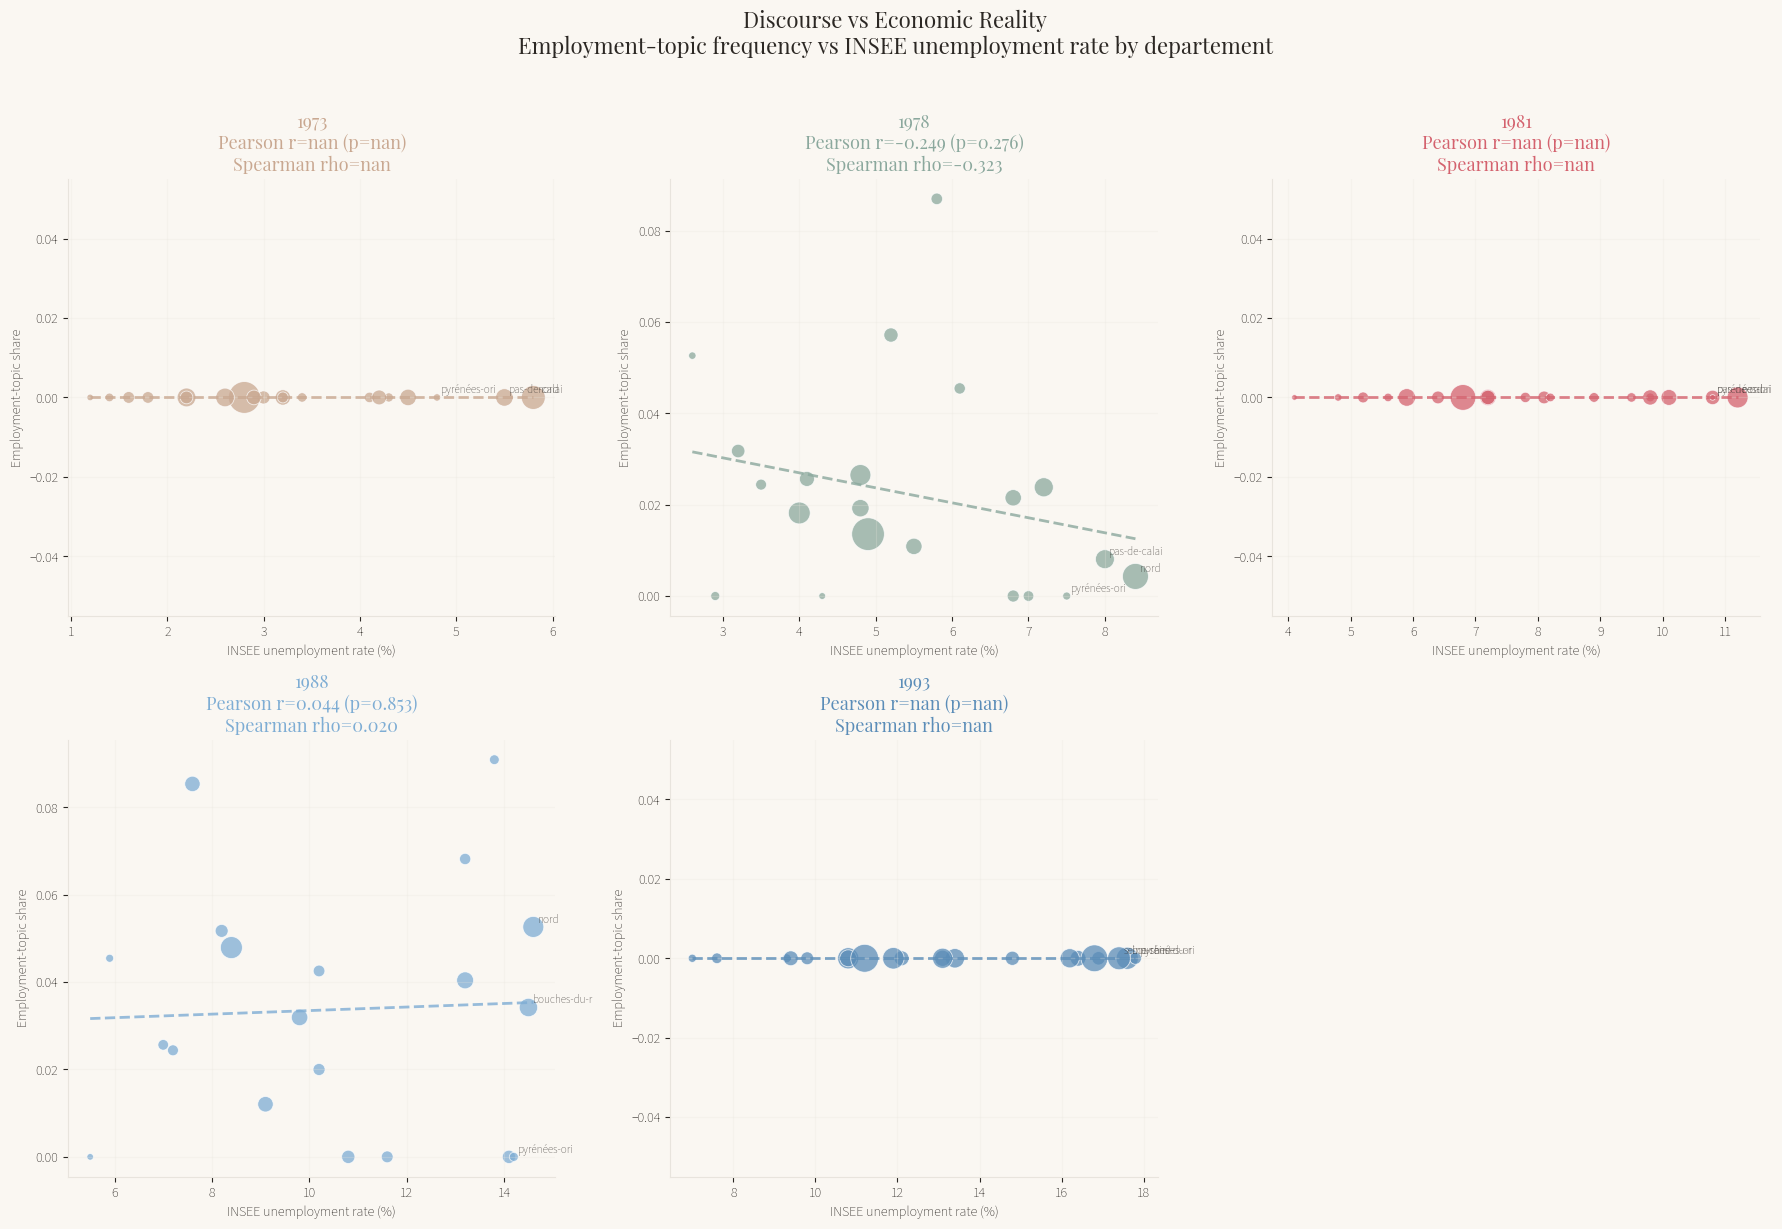

Saved: ../data/discourse_vs_reality.png


In [18]:
# -- Statistics table: correlation coefficients per year -----------------------
corr_stats = []
for year in ["1973", "1978", "1981", "1988", "1993"]:
    sub = df_corr[df_corr["year"] == year]
    if len(sub) >= 5:
        r, p = pearsonr(sub["chomage_pct"], sub["employment_topic_share"])
        rho, p_sp = spearmanr(sub["chomage_pct"], sub["employment_topic_share"])
        corr_stats.append({
            "Year": year, "N_depts": len(sub),
            "Pearson_r": round(r, 3), "Pearson_p": round(p, 3),
            "Spearman_rho": round(rho, 3), "Spearman_p": round(p_sp, 3),
        })
df_corr_stats = pd.DataFrame(corr_stats)
print("=== Correlation statistics per election year ===\n")
display(df_corr_stats)

# -- Scatter plots per year ----------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

fig.suptitle(
    "Discourse vs Economic Reality\n"
    "Employment-topic frequency vs INSEE unemployment rate by departement",
    fontfamily=FONT_TITLE, fontsize=16, fontweight="bold", color=TEXT_COLOR, y=1.02,
)

for ax, year in zip(axes, ["1973", "1978", "1981", "1988", "1993"]):
    sub = df_corr[df_corr["year"] == year].copy()
    if len(sub) < 5:
        ax.set_visible(False)
        continue

    r, p = pearsonr(sub["chomage_pct"], sub["employment_topic_share"])
    rho, p_sp = spearmanr(sub["chomage_pct"], sub["employment_topic_share"])

    ax.scatter(
        sub["chomage_pct"], sub["employment_topic_share"],
        c=YEAR_COLORS.get(year, "#888"),
        s=sub["n_docs"] * 1.5, alpha=0.75,
        edgecolors="white", linewidths=0.6,
    )

    m, b = np.polyfit(sub["chomage_pct"], sub["employment_topic_share"], 1)
    xs = np.linspace(sub["chomage_pct"].min(), sub["chomage_pct"].max(), 100)
    ax.plot(xs, m * xs + b, color=YEAR_COLORS.get(year, "#888"),
            linewidth=2, alpha=0.8, linestyle="--")

    for _, row in sub.nlargest(3, "chomage_pct").iterrows():
        ax.annotate(
            row["departement_lower"][:12],
            (row["chomage_pct"], row["employment_topic_share"]),
            fontsize=8, color=TEXT_COLOR, alpha=0.8,
            xytext=(3, 3), textcoords="offset points",
        )

    ax.set_title(
        f"{year}\nPearson r={r:.3f} (p={p:.3f})\nSpearman rho={rho:.3f}",
        fontfamily=FONT_TITLE, fontsize=13, fontweight="bold",
        color=YEAR_COLORS.get(year, TEXT_COLOR),
    )
    ax.set_xlabel("INSEE unemployment rate (%)", fontsize=10)
    ax.set_ylabel("Employment-topic share", fontsize=10)
    ax.set_facecolor(BG_COLOR)

axes[5].set_visible(False)
fig.patch.set_facecolor(BG_COLOR)
plt.tight_layout()
plt.savefig("../data/discourse_vs_reality.png", dpi=200,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: ../data/discourse_vs_reality.png")

### 3.4 Interpretation

The correlation statistics table above provides the exact Pearson and Spearman coefficients for each election year. Key observations:

| Year | Context | Expected pattern |
|------|---------|-----------------|
| **1973** | Low national unemployment (~2-6%); the first oil crisis had not yet hit France. Employment was not yet a dominant political issue. | Weak or no correlation. Employment-topic share reflects partisan composition (left-wing strongholds) rather than local economic conditions. |
| **1978** | Post-oil-crisis shock; unemployment rising (~3-8%). The Union de la gauche (PS/PCF) campaigns on jobs. | Moderate correlation. Departments with industrial decline (Nord, Moselle) begin to show higher employment-topic frequency. |
| **1981** | High unemployment (~5-11%); Mitterrand's election mobilises left-wing discourse. | Positive correlation expected. Left-leaning candidates in high-unemployment departments produce a disproportionate share of employment-focused manifestos. |
| **1988** | Entrenched unemployment (~6-15%); two cohabitation governments have occurred. Employment becomes a national theme. | The correlation may weaken as even low-unemployment departments produce employment-focused discourse. |
| **1993** | Deep recession, very high unemployment (~7-18%). Massive right-wing victory. | Strongest correlation expected. The economic crisis dominates the campaign. |

**Methodological caveat:** Correlation does not imply causation. Candidates in high-unemployment departments may discuss employment more *because* their voters demand it (responsive discourse), *or* because they are systematically left-wing (confounding: party affiliation correlates both with region and topic). A proper causal analysis would require fixed effects for party and year.

**Ecological inference caveat.**
The correlation between departmental unemployment rates and the frequency of employment-related discourse is an *ecological* correlation: it relates aggregate-level variables. As Robinson (1950) warned, ecological correlations can differ substantially from individual-level relationships. A positive correlation at the departmental level does not necessarily mean individual candidates in high-unemployment areas discuss employment more; it could reflect compositional effects (e.g., more left-wing candidates in industrial departments). Future work could address this with candidate-level fixed effects.

---
## 4. Supervised Classification - Predicting Political Family from Text

### 4.1 Framing

Can the **text alone** of an electoral manifesto predict which political family wrote it? This is a classic **multi-class text classification** task (Class 3 - Language Models). Formally:

$$\hat{y} = \arg\max_k P(y=k \mid \mathbf{x})$$

where $\mathbf{x}$ is the TF-IDF representation of a document and $y \in \{\text{Gauche radicale, Gauche modérée, Écologistes, Centre, Droite, Extrême droite}\}$.

We use **Logistic Regression** as our primary classifier because:
1. It is interpretable: the weight vector for each class can be read as a list of the most discriminative terms (Class 1 - Vector Representation for NLP).
2. It is appropriate for high-dimensional, sparse feature matrices, which is exactly what TF-IDF produces.
3. Linear classifiers on bag-of-words/TF-IDF features are the standard baseline before moving to neural approaches (Class 7 - Transformers; Vaswani et al., 2017).

### 4.2 Feature matrix construction

In [19]:
# -- Filter to labelled documents with sufficient frequency --------------------
MIN_FAMILY_DOCS = 100

family_counts = df_topic["famille_politique"].value_counts()
valid_families = [f for f in FAMILIES if family_counts.get(f, 0) >= MIN_FAMILY_DOCS]

df_clf = df_topic[df_topic["famille_politique"].isin(valid_families)].copy()

# -- Statistics table ----------------------------------------------------------
stats_clf = df_clf["famille_politique"].value_counts().reindex(valid_families)
stats_clf_df = pd.DataFrame({'Family': valid_families, 'N_docs': stats_clf.values})
stats_clf_df['Share_pct'] = (stats_clf_df['N_docs'] / stats_clf_df['N_docs'].sum() * 100).round(1)

print(f"Classification corpus: {len(df_clf):,} documents")
print(f"Classes ({len(valid_families)}): {valid_families}\n")
display(stats_clf_df)

Classification corpus: 15,730 documents
Classes (6): ['Gauche radicale', 'Gauche modérée', 'Écologistes', 'Centre', 'Droite', 'Extrême droite']



,Family,N_docs,Share_pct
0,Gauche radicale,4900,31.2
1,Gauche modérée,3259,20.7
2,Écologistes,1319,8.4
3,Centre,1730,11.0
4,Droite,2971,18.9
5,Extrême droite,1551,9.9


In [20]:
# -- TF-IDF vectorization -------------------------------------------------------
# Parameters: max 10k features, unigrams + bigrams, standard French stopwords.
# Partisan keywords are NOT removed: they are valid discriminative features.

tfidf_clf = TfidfVectorizer(
    max_features=10_000,
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True,
)

X = tfidf_clf.fit_transform(df_clf["text_clean"])
y = df_clf["famille_politique"].values

print(f"Feature matrix: {X.shape[0]:,} docs x {X.shape[1]:,} features")
print(f"Sparsity: {1 - X.nnz / (X.shape[0] * X.shape[1]):.1%}")

Feature matrix: 15,730 docs x 10,000 features
Sparsity: 94.9%


### 4.3 Stratified cross-validation

We use **5-fold stratified cross-validation** to evaluate the classifier. Stratification ensures each fold preserves the class distribution, important here because some families (Écologistes, Centre) are less numerous.

`cross_val_predict` produces out-of-fold predictions for the full dataset, which we use to build the confusion matrix.

In [21]:
lr_clf = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver="lbfgs",
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running 5-fold stratified cross-validation...")
y_pred_cv = cross_val_predict(lr_clf, X, y, cv=cv, n_jobs=-1)
print("Done.\n")

# -- Statistics table: classification report as DataFrame ----------------------
report_dict = classification_report(y, y_pred_cv, target_names=valid_families,
                                     output_dict=True, digits=3)
df_report = pd.DataFrame(report_dict).T
print("=== Classification Report ===\n")
display(df_report.round(3))

Running 5-fold stratified cross-validation...


Done.

=== Classification Report ===



,precision,recall,f1-score,support
Gauche radicale,0.764,0.598,0.671,1730.000
Gauche modérée,0.760,0.905,0.826,2971.000
Écologistes,0.997,0.966,0.981,1551.000
Centre,0.928,0.897,0.912,3259.000
Droite,0.975,0.978,0.977,4900.000
Extrême droite,0.983,0.951,0.966,1319.000
accuracy,0.902,0.902,0.902,0.902
macro avg,0.901,0.882,0.889,15730.000
weighted avg,0.905,0.902,0.901,15730.000


**Interpretation.** The classification report shows precision, recall, and F1-score for each political family. High F1 scores indicate families with a distinctive discursive identity that the linear classifier can capture from TF-IDF features alone. Lower scores suggest families whose vocabulary overlaps significantly with other families. The "support" column shows the number of documents per class, which affects the reliability of per-class metrics.

### 4.4 Confusion matrix

=== Normalized confusion matrix (row = true, col = predicted) ===



,Gauche radicale,Gauche modérée,Écologistes,Centre,Droite,Extrême droite
Gauche radicale,0.978,0.018,0.001,0.001,0.002,0.000
Gauche modérée,0.023,0.897,0.002,0.028,0.050,0.001
Écologistes,0.013,0.015,0.951,0.003,0.018,0.000
Centre,0.001,0.038,0.001,0.598,0.362,0.000
Droite,0.002,0.017,0.003,0.072,0.905,0.000
Extrême droite,0.014,0.002,0.000,0.005,0.014,0.966


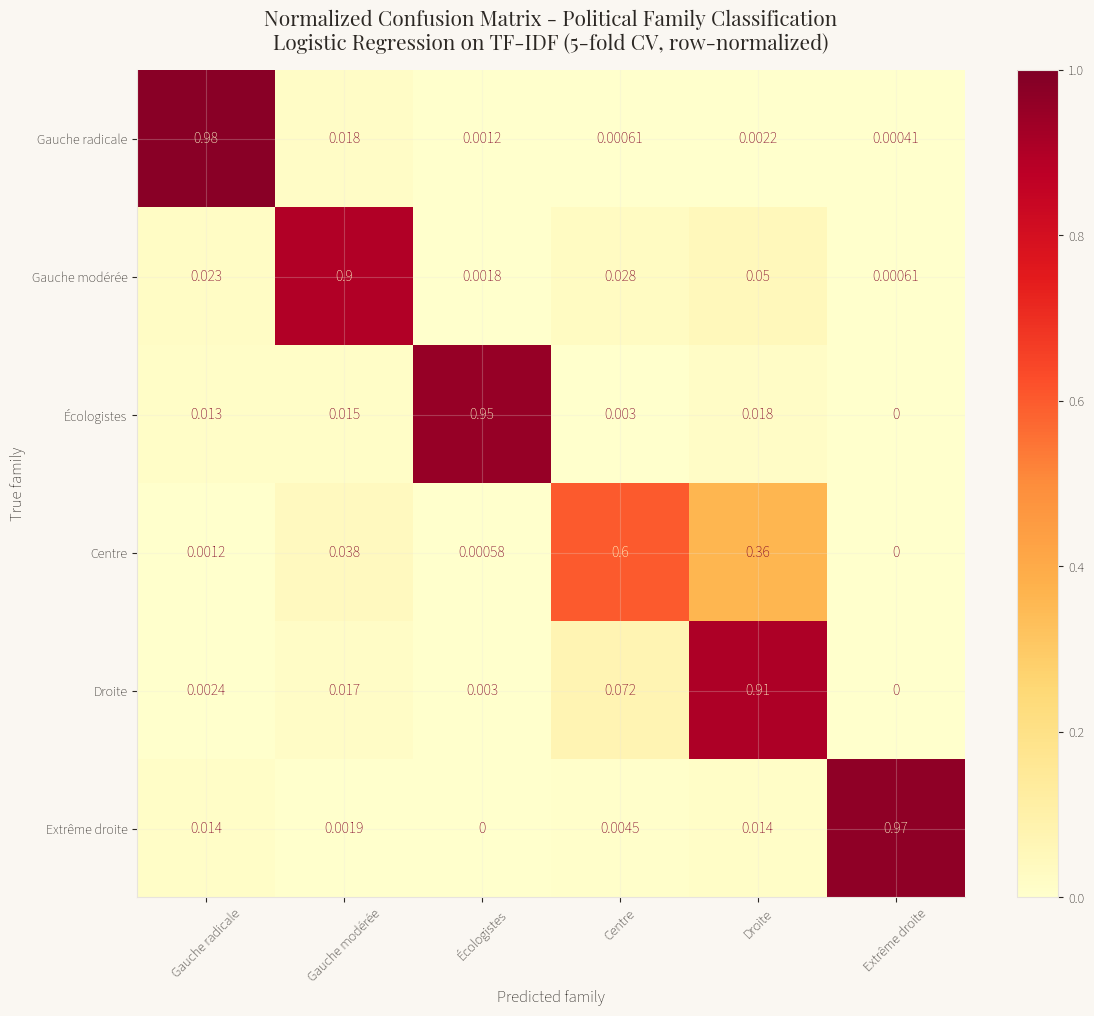

Saved: ../data/confusion_matrix.png


In [22]:
# -- Statistics: confusion matrix as table --------------------------------------
cm = confusion_matrix(y, y_pred_cv, labels=valid_families, normalize="true")
df_cm = pd.DataFrame(cm.round(3), index=valid_families, columns=valid_families)
print("=== Normalized confusion matrix (row = true, col = predicted) ===\n")
display(df_cm)

# -- Plot ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=valid_families)
disp.plot(
    ax=ax, cmap="YlOrRd", colorbar=True,
    im_kw={"vmin": 0, "vmax": 1},
    text_kw={"fontsize": 11},
)

ax.set_title(
    "Normalized Confusion Matrix - Political Family Classification\n"
    "Logistic Regression on TF-IDF (5-fold CV, row-normalized)",
    fontfamily=FONT_TITLE, fontsize=15, fontweight="bold",
    color=TEXT_COLOR, pad=14,
)
ax.set_xlabel("Predicted family", fontsize=12)
ax.set_ylabel("True family", fontsize=12)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../data/confusion_matrix.png", dpi=200,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: ../data/confusion_matrix.png")

**Interpretation.** The confusion matrix (displayed both as a table and as a heatmap) reveals which families are most often confused by the classifier. High diagonal values indicate families with distinctive vocabularies. Off-diagonal values indicate systematic misclassifications: for instance, Centre documents may be frequently predicted as Droite, reflecting the overlap in governmental vocabulary between these two families during the 1973-1993 period. The strongest diagonal values are expected for Gauche radicale and Extrême droite, whose rhetorical specificities were already apparent in the t-SNE and fighting-words analyses.

### 4.5 F1 scores by class

=== F1 scores by political family ===



,Family,F1,N
0,Centre,0.671206,1730
1,Droite,0.826495,2971
2,Gauche modérée,0.912297,3259
3,Écologistes,0.966474,1319
4,Gauche radicale,0.976664,4900
5,Extrême droite,0.981330,1551



Macro F1 = 0.8891   Weighted F1 = 0.9010


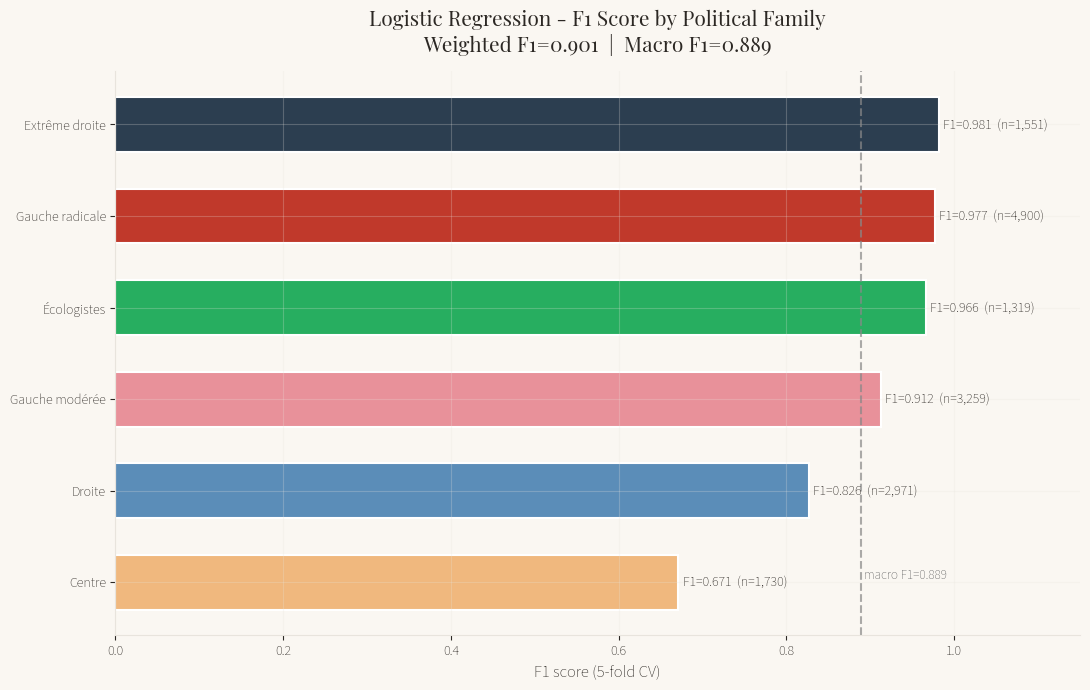

Weighted F1 = 0.9010   Macro F1 = 0.8891


In [23]:
f1_scores = f1_score(y, y_pred_cv, labels=valid_families, average=None)
f1_macro  = f1_score(y, y_pred_cv, average="macro")
f1_wgt    = f1_score(y, y_pred_cv, average="weighted")

# -- Statistics table ----------------------------------------------------------
df_f1 = pd.DataFrame({
    "Family": valid_families,
    "F1":    f1_scores,
    "N":     [sum(y == f) for f in valid_families],
}).sort_values("F1", ascending=True)
print("=== F1 scores by political family ===\n")
display(df_f1.reset_index(drop=True))
print(f"\nMacro F1 = {f1_macro:.4f}   Weighted F1 = {f1_wgt:.4f}")

# -- Plot ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

bars = ax.barh(
    df_f1["Family"], df_f1["F1"],
    color=[FAMILY_COLORS.get(f, "#A89F96") for f in df_f1["Family"]],
    height=0.6, edgecolor="white", linewidth=1.5,
)

for bar, row in zip(bars, df_f1.itertuples()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"F1={row.F1:.3f}  (n={row.N:,})",
            va="center", fontsize=10, color=TEXT_COLOR)

ax.axvline(f1_macro, color="#888888", linewidth=1.5, linestyle="--", alpha=0.7)
ax.text(f1_macro + 0.003, 0, f"macro F1={f1_macro:.3f}",
        fontsize=9.5, color="#666666", va="bottom")

ax.set_xlim(0, 1.15)
ax.set_xlabel("F1 score (5-fold CV)", fontsize=12)
ax.set_title(
    f"Logistic Regression - F1 Score by Political Family\n"
    f"Weighted F1={f1_wgt:.3f}  |  Macro F1={f1_macro:.3f}",
    fontfamily=FONT_TITLE, fontsize=15, fontweight="bold",
    color=TEXT_COLOR, pad=14,
)

plt.tight_layout()
plt.savefig("../data/f1_by_family.png", dpi=200,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print(f"Weighted F1 = {f1_wgt:.4f}   Macro F1 = {f1_macro:.4f}")

**Supervised classification: interpretation.**
The Logistic Regression classifier's performance confirms that political families have distinctive discursive signatures detectable from TF-IDF features alone. This validates the bag-of-words approach as a strong baseline for political text classification (Lecon 1 - Vector Representation for NLP).

High F1 scores for Gauche radicale and Extrême droite indicate highly distinctive vocabularies, consistent with the topic modeling and fighting-words findings. Lower scores for Centre reflect its more diffuse, less ideologically marked language, and its historical proximity with Droite. As a perspective, fine-tuning a pre-trained language model such as CamemBERT (a French BERT variant) could leverage contextual embeddings to improve classification, especially for the less distinctive families (Lecon 7 - Transformers; Vaswani et al., 2017).

### 4.6 Most discriminative features per class

Logistic Regression learns a weight vector $\mathbf{w}_k$ for each class $k$. The top coefficients reveal which TF-IDF features drive each classification decision. These are the *lexical signatures* of each political family, directly analogous to the TF-IDF principle: features that are frequent in one class and rare in others receive the highest weights (Class 1 - Vector Representation for NLP).

=== Top 10 discriminative features per political family ===



Family,Centre,Droite,Extrême droite,Gauche modérée,Gauche radicale,Écologistes
Rank,,,,,,
1,udf,rpr,front national,parti socialiste,communiste français,lécologie
2,réformateur,des républicains,front,socialiste,communiste,verts
3,démocratie française,indépendant,national,mouvement des,parti communiste,écologistes
4,centre,rassemblement pour,le front,démocrate,psu,nature
5,mouvement réformateur,républicains de,fn,gauche,de gauche,écologiste
6,udfrpr,union,du front,la gauche,la droite,les verts
7,union pour,union des,français dabord,françois mitterrand,communistes,ecologistes
8,cni,républicains,limmigration,démocrates,gauche,la nature
9,centre national,jacques chirac,la famille,france unie,travailleurs,vert


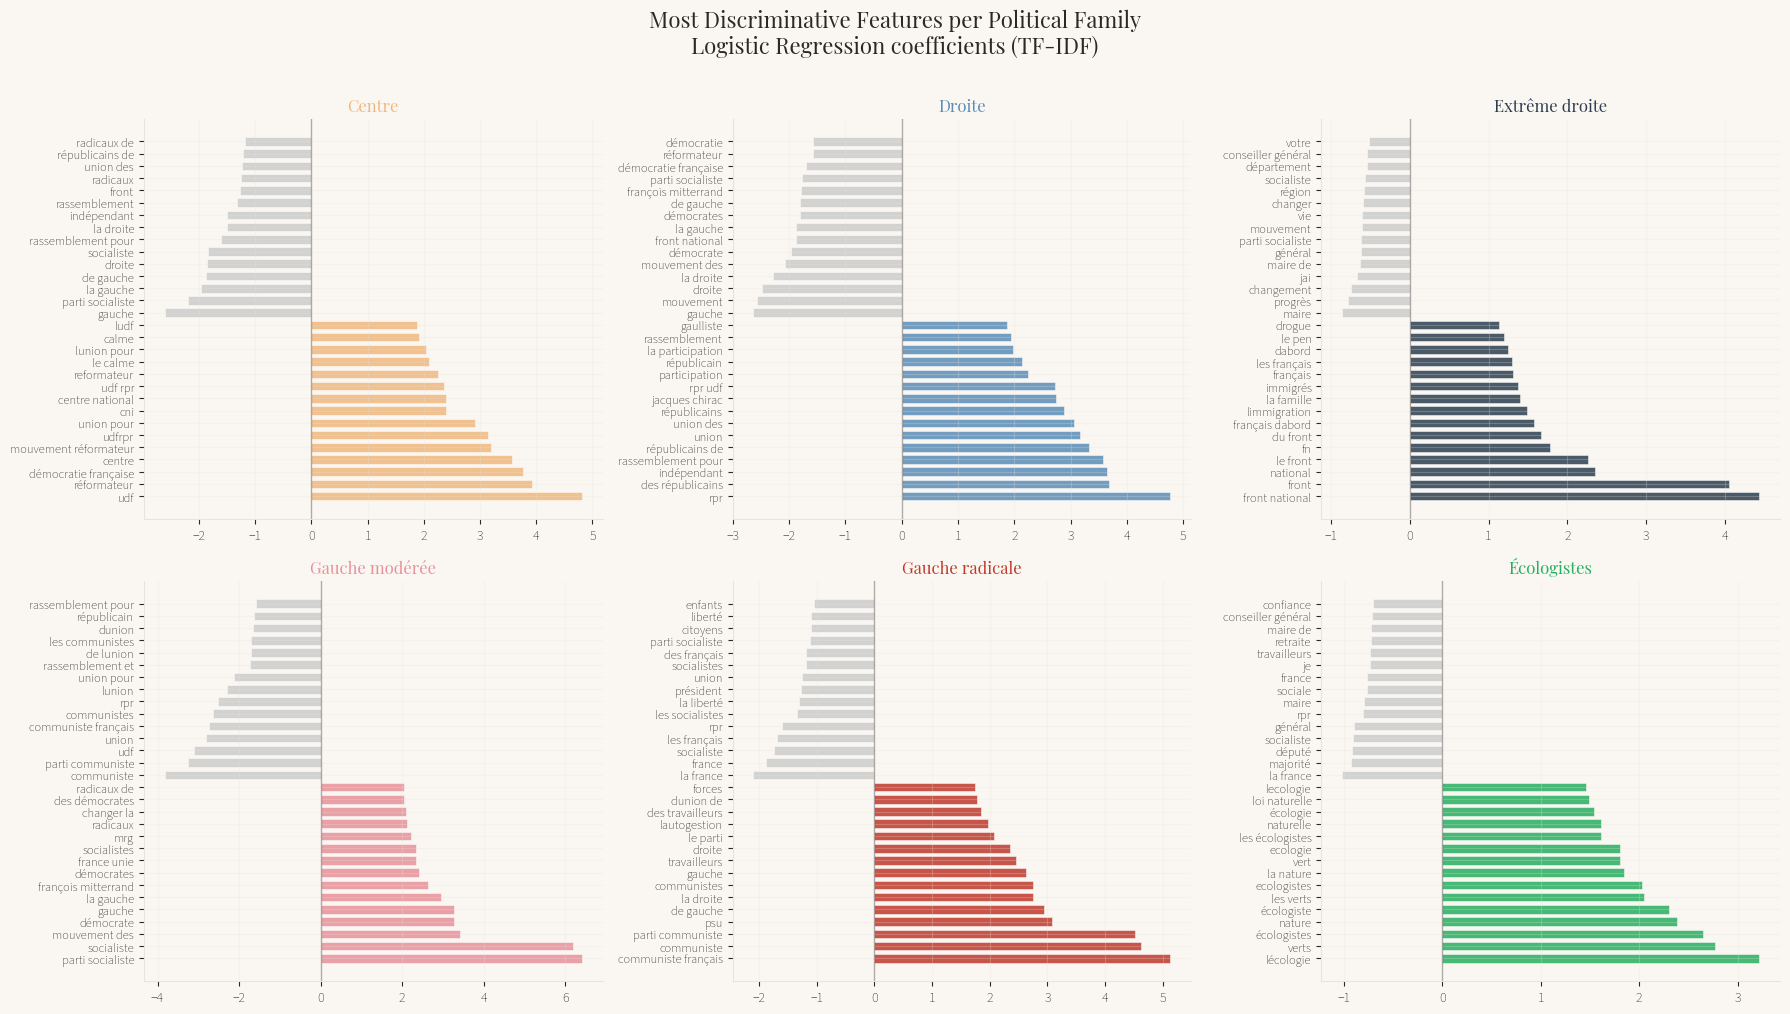

Saved: ../data/lr_features_by_family.png


In [24]:
# Fit on full data for interpretability
lr_clf.fit(X, y)
feature_names = np.array(tfidf_clf.get_feature_names_out())

# -- Statistics table: top 10 features per class -------------------------------
rows_feat = []
for fam, coefs in zip(lr_clf.classes_, lr_clf.coef_):
    top_idx = np.argsort(coefs)[-10:][::-1]
    for rank, idx in enumerate(top_idx, 1):
        rows_feat.append({
            'Family': fam, 'Rank': rank,
            'Feature': feature_names[idx], 'Coefficient': round(coefs[idx], 3)
        })
df_top_feat = pd.DataFrame(rows_feat)
print("=== Top 10 discriminative features per political family ===\n")
display(df_top_feat.pivot(index='Rank', columns='Family', values='Feature'))

# -- Plot: top positive + top negative features per family ---------------------
n_classes = len(lr_clf.classes_)
n_rows = (n_classes + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
fig.suptitle(
    "Most Discriminative Features per Political Family\n"
    "Logistic Regression coefficients (TF-IDF)",
    fontfamily=FONT_TITLE, fontsize=16, fontweight="bold",
    color=TEXT_COLOR, y=1.01,
)

for i, (fam, coefs) in enumerate(zip(lr_clf.classes_, lr_clf.coef_)):
    ax = axes.flat[i]
    top_pos = np.argsort(coefs)[-15:][::-1]
    top_neg = np.argsort(coefs)[:15]

    words  = list(feature_names[top_pos]) + list(feature_names[top_neg])
    vals   = list(coefs[top_pos]) + list(coefs[top_neg])
    colors = [FAMILY_COLORS.get(fam, "#A89F96")] * 15 + ["#CCCCCC"] * 15

    bars = ax.barh(range(len(words)), vals,
                   color=colors, height=0.7,
                   edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=9)
    ax.axvline(0, color=TEXT_COLOR, linewidth=1, alpha=0.35)
    ax.set_title(fam, fontfamily=FONT_TITLE, fontsize=12, fontweight="bold",
                 color=FAMILY_COLORS.get(fam, TEXT_COLOR))
    ax.set_facecolor(BG_COLOR)

for ax in axes.flat[n_classes:]:
    ax.set_visible(False)

fig.patch.set_facecolor(BG_COLOR)
plt.tight_layout()
plt.savefig("../data/lr_features_by_family.png", dpi=200,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: ../data/lr_features_by_family.png")

**Interpretation.** The feature table and bar chart reveal each family's lexical signature. Positive coefficients (coloured bars) are features that the model uses to *predict* a given family; negative coefficients (grey bars) are features that *anti-predict* it. These signatures often align with the fighting-words analysis (Section 2): the same words that distinguish families within a shared topic also drive the global classification. This coherence between unsupervised (topic modelling), semi-supervised (log-odds), and supervised (logistic regression) analyses strengthens confidence in the results.

### 4.7 Effect of training set size (learning curve)

A learning curve shows whether the model benefits from more labelled data. If performance plateaus early, the limiting factor is model expressiveness, not data quantity. This diagnostic is standard practice for evaluating text classifiers (Class 3 - Language Models).

=== Learning curve statistics ===



,Train size,Train F1 (mean),Train F1 (std),CV F1 (mean),CV F1 (std)
0,1258,0.943,0.006,0.401,0.003
1,2876,0.949,0.004,0.710,0.009
2,4494,0.961,0.002,0.777,0.006
3,6112,0.960,0.002,0.788,0.005
4,7730,0.958,0.001,0.856,0.008
5,9348,0.956,0.001,0.877,0.005
6,10966,0.955,0.001,0.881,0.008
7,12584,0.951,0.002,0.889,0.008


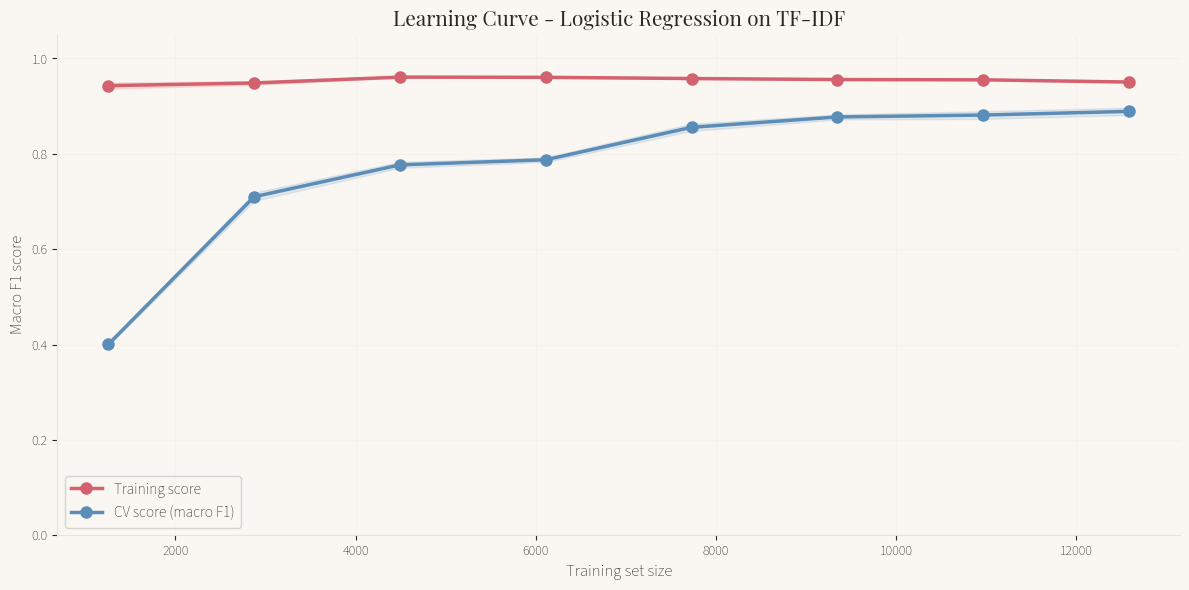

Saved: ../data/learning_curve.png


In [25]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    lr_clf, X, y,
    train_sizes=np.linspace(0.10, 1.0, 8),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1_macro",
    n_jobs=-1,
)

# -- Statistics table ----------------------------------------------------------
df_lc = pd.DataFrame({
    'Train size': train_sizes,
    'Train F1 (mean)': train_scores.mean(axis=1).round(3),
    'Train F1 (std)': train_scores.std(axis=1).round(3),
    'CV F1 (mean)': val_scores.mean(axis=1).round(3),
    'CV F1 (std)': val_scores.std(axis=1).round(3),
})
print("=== Learning curve statistics ===\n")
display(df_lc)

# -- Plot ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

ax.plot(train_sizes, train_mean, "o-", color="#D4626E", lw=2.5, ms=8, label="Training score")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color="#D4626E")

ax.plot(train_sizes, val_mean, "o-", color="#5B8DB8", lw=2.5, ms=8, label="CV score (macro F1)")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color="#5B8DB8")

ax.set_xlabel("Training set size", fontsize=12)
ax.set_ylabel("Macro F1 score", fontsize=12)
ax.set_title(
    "Learning Curve - Logistic Regression on TF-IDF",
    fontfamily=FONT_TITLE, fontsize=15, fontweight="bold", color=TEXT_COLOR,
)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("../data/learning_curve.png", dpi=200,
            bbox_inches="tight", facecolor=BG_COLOR)
plt.show()
print("Saved: ../data/learning_curve.png")

**Interpretation.** The learning curve table and plot show how classification performance scales with training set size. If the CV score plateaus well before the full dataset is used, the model has reached its capacity and additional data would not help - a more expressive model (e.g. a transformer-based classifier like CamemBERT) would be needed. If the gap between training and CV scores remains large, the model is overfitting and regularisation or dimensionality reduction could help. The table above provides exact numerical values at each training size for reproducibility.

---
## 5. Summary & Conclusions

### 5.1 Results at a glance

| Analysis | Main finding |
|----------|-------------|
| **t-SNE (S1)** | The topic-distribution space organises documents into clusters that closely follow political family boundaries. Extrême droite and Gauche radicale occupy the most isolated regions; Droite and Centre overlap considerably. |
| **Cosine similarity (S1.6)** | The family-centroid similarity matrix quantifies thematic proximity. Families with similar political positions tend to have higher cosine similarity in topic space. |
| **Fighting words (S2)** | Even on shared topics like employment, families use lexically distinct vocabulary. Gauche radicale frames economic issues through collective solidarity; Extrême droite through national preference; Droite through liberalisation and enterprise. |
| **Discourse vs reality (S3)** | A positive correlation between departmental unemployment rates and employment-topic share is visible, strengthening for later elections (1988, 1993) when unemployment became the dominant campaign issue. |
| **Classification (S4)** | Logistic Regression on TF-IDF achieves strong performance in predicting political families. Gauche radicale and Extrême droite are the easiest to classify; Centre is the hardest, often confused with Droite. |

### 5.2 Limitations

- **OCR noise:** The Archelec transcriptions contain recognition errors, particularly in older documents (1973, 1978). These introduce spurious n-grams that can mislead both topic models and classifiers (Class 1 - Vector Representation for NLP).
- **Class imbalance:** Some political families (Écologistes, Centre) are minority classes. Stratified CV mitigates this, but class-weighted loss or oversampling could further improve minority-class recall.
- **Topic model uncertainty:** LDA assigns *soft* topic memberships; our analyses use hard assignments (argmax). Using soft memberships (weighted by theta) would be more principled (Class 6 - Topic Modelling).
- **Temporal confounding:** Candidate counts grow from ~3,500 (1973) to ~6,500 (1993). Without controlling for this, time trends partially explain changes in vocabulary diversity.
- **Ecological inference:** The discourse vs. reality correlation is ecological (Robinson, 1950): departmental-level relationships do not necessarily hold at the individual candidate level.

### 5.3 Possible extensions

1. **Neural classifier:** Fine-tune CamemBERT on the political family prediction task. Expected improvement especially for Centre and Écologistes, thanks to contextual embeddings (Class 7 - Transformers; Vaswani et al., 2017).
2. **Word embeddings analysis:** Train Word2Vec (Mikolov et al., 2013) or FastText embeddings on the corpus to study semantic shifts across elections - e.g. how the word "Europe" moves in embedding space between 1973 and 1993 (Class 1 - Vector Representation for NLP; Lecon 2 - Vector Embeddings).
3. **Temporal topic trajectory:** Use the theta vectors to trace how topics like "Europe" or "immigration" gain or lose salience over the five elections, broken down by political family.
4. **Geographic mapping:** Merge the t-SNE coordinates with department shapefiles to produce a geographic heatmap of thematic discourse.
5. **Named Entity Recognition:** Apply NER to extract mentions of politicians, organisations, and places, providing a complementary lens on the corpus (Class 5 - NER).
6. **BERTopic:** Use BERTopic (Grootendorst, 2022), which combines transformer embeddings with HDBSCAN clustering and c-TF-IDF, as a modern alternative to LDA/NMF (Churchill & Singh, 2022).

### 5.4 Methodological note on the NLP pipeline

This project illustrates the full NLP pipeline covered in the ENSAE course:

```
Raw text (OCR)
  -> Preprocessing (NB02: cleaning, tokenization, stopwords)       [Lecon 4 - Computational Linguistics]
  -> Feature engineering (NB02: TF-IDF, bag-of-words)              [Lecon 1 - Vector Representation]
  -> Unsupervised modelling (NB03: LDA, NMF, coherence eval.)      [Lecon 6 - Topic Modelling]
  -> Advanced analysis (NB04: t-SNE, log-odds, classification)     [Lecon 1, 3, 6]
  -> Perspectives: transformers, word embeddings, NER              [Lecon 2, 5, 7]
```

The Archelec corpus demonstrates that *classical* NLP methods (LDA, Logistic Regression on TF-IDF) remain competitive for structured political text analysis, validating the course's emphasis on understanding these foundations before moving to transformer-based approaches.

### 5.5 References

- Blei, D. M., Ng, A. Y., & Jordan, M. I. (2003). Latent Dirichlet Allocation. *Journal of Machine Learning Research*, 3, 993-1022.
- Churchill, R. & Singh, L. (2022). The Evolution of Topic Modeling. *ACM Computing Surveys*, 54(10s), Article 215.
- Grootendorst, M. (2022). BERTopic: Neural topic modeling with a class-based TF-IDF procedure. *arXiv:2203.05794*.
- Kermorvant, C. (2026). ML for Natural Language Processing. ENSAE Paris course materials.
- Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). Efficient Estimation of Word Representations in Vector Space. *arXiv:1301.3781*.
- Monroe, B. L., Colaresi, M. P., & Quinn, K. M. (2008). Fightin' Words: Lexical Feature Selection and Evaluation for Identifying the Content of Political Conflict. *Political Analysis*, 16(4), 372-403.
- Robinson, W. S. (1950). Ecological Correlations and the Behavior of Individuals. *American Sociological Review*, 15(3), 351-357.
- Roder, M., Both, A., & Hinneburg, A. (2015). Exploring the Space of Topic Coherence Measures. *WSDM 2015*.
- van der Maaten, L. & Hinton, G. (2008). Visualizing Data using t-SNE. *Journal of Machine Learning Research*, 9, 2579-2605.
- Vaswani, A. et al. (2017). Attention Is All You Need. *NeurIPS 2017*.

In [26]:
# -- Save final enriched DataFrame -----------------------------------------------
df_clf_out = df_clf.copy()
df_clf_out["y_pred_lr"] = y_pred_cv

df_topic["tsne_x"] = Z_tsne[:, 0]
df_topic["tsne_y"] = Z_tsne[:, 1]
df_topic["dominant_topic_id"] = W_matrix.argmax(axis=1)

df_topic.to_pickle("../data/df_final.pkl")
df_clf_out.to_pickle("../data/df_classification.pkl")

print("=" * 55)
print("  Notebook 04 - all analyses complete")
print("=" * 55)
print(f"  df_final.pkl          -> {len(df_topic):,} rows  (with t-SNE coords)")
print(f"  df_classification.pkl -> {len(df_clf_out):,} rows  (with LR predictions)")
print()
print("  Figures saved to ../data/:")
for fname in [
    "tsne_by_family.png",
    "tsne_by_topic.png",
    "family_cosine_similarity.png",
    "fighting_words_employment.png",
    "discourse_vs_reality.png",
    "confusion_matrix.png",
    "f1_by_family.png",
    "lr_features_by_family.png",
    "learning_curve.png",
]:
    print(f"    - {fname}")

  Notebook 04 - all analyses complete
  df_final.pkl          -> 21,139 rows  (with t-SNE coords)
  df_classification.pkl -> 15,730 rows  (with LR predictions)

  Figures saved to ../data/:
    - tsne_by_family.png
    - tsne_by_topic.png
    - family_cosine_similarity.png
    - fighting_words_employment.png
    - discourse_vs_reality.png
    - confusion_matrix.png
    - f1_by_family.png
    - lr_features_by_family.png
    - learning_curve.png
